<a href="https://colab.research.google.com/github/peyste/SMGT490Project/blob/main/SMGT490_GMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nflreadpy

In [ ]:
import pandas as pd
import numpy as np
from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

print("--- STEP 1: LOADING & MERGING PFF DATA ---")
years = range(2020, 2026)
all_years_data = []

for year in years:
    yearly_dfs = []

    # 1. Base Coverage
    try:
        cov = pd.read_csv(f"{year}_defense_coverage_summary.csv")
        cov_cols = ['player', 'player_id', 'position', 'team_name', 'snap_counts_coverage',
                    'grades_coverage_defense', 'grades_defense', 'targets', 'interceptions', 'pass_break_ups',
                    'forced_incompletion_rate', 'coverage_percent']
        cov = cov[[c for c in cov_cols if c in cov.columns]]
        yearly_dfs.append(cov)
    except FileNotFoundError: pass

    # 2. Coverage Scheme
    try:
        scheme = pd.read_csv(f"{year}_defense_coverage_scheme.csv")
        scheme_cols = ['player_id', 'man_snap_counts_coverage', 'zone_snap_counts_coverage', 'man_grades_coverage_defense', 'zone_grades_coverage_defense']
        scheme = scheme[[c for c in scheme_cols if c in scheme.columns]]
        yearly_dfs.append(scheme)
    except FileNotFoundError: pass

    # 3. Pass Rush
    try:
        pr = pd.read_csv(f"{year}_pass_rush_summary.csv")
        pr_cols = ['player_id', 'snap_counts_pass_rush', 'grades_pass_rush_defense',
                   'total_pressures', 'pass_rush_win_rate', 'sacks']
        pr = pr[[c for c in pr_cols if c in pr.columns]]
        yearly_dfs.append(pr)
    except FileNotFoundError: pass

    # 4. Run Defense
    try:
        run = pd.read_csv(f"{year}_run_defense_summary.csv")
        run_cols = ['player_id', 'snap_counts_run', 'grades_run_defense', 'stop_percent']
        run = run[[c for c in run_cols if c in run.columns]]
        yearly_dfs.append(run)
    except FileNotFoundError: pass

    # 5. Slot Coverage (Now correctly mapped)
    try:
        slot = pd.read_csv(f"{year}_slot_coverage.csv")
        if 'coverage_snaps' in slot.columns:
            slot = slot[['player_id', 'coverage_snaps']].rename(columns={'coverage_snaps': 'slot_snap_counts'})
        elif 'snap_counts_coverage' in slot.columns:
            slot = slot[['player_id', 'snap_counts_coverage']].rename(columns={'snap_counts_coverage': 'slot_snap_counts'})
        yearly_dfs.append(slot)
    except FileNotFoundError: pass

    # 6. Defense Summary (New snap counts)
    try:
        defense_summary = pd.read_csv(f"{year}_defense_summary.csv")
        defense_summary_cols = ['player_id', 'snap_counts_box', 'snap_counts_corner', 'snap_counts_dl',
                                'snap_counts_fs', 'snap_counts_slot', 'snap_counts_dl_a_gap',
                                'snap_counts_dl_b_gap', 'snap_counts_dl_outside_t', 'snap_counts_dl_over_t']
        defense_summary = defense_summary[[c for c in defense_summary_cols if c in defense_summary.columns]]
        yearly_dfs.append(defense_summary)
    except FileNotFoundError: pass

    if yearly_dfs:
        merged_year = reduce(lambda left, right: pd.merge(left, right, on='player_id', how='outer'), yearly_dfs)
        merged_year['season'] = year
        all_years_data.append(merged_year)

df = pd.concat(all_years_data, ignore_index=True)
df = df.dropna(subset=['player', 'position'])

print("--- STEP 2: CLEANING & IMPUTING NaNs ---")
df['total_snaps'] = df['snap_counts_run'].fillna(0) + df['snap_counts_pass_rush'].fillna(0) + df['snap_counts_coverage'].fillna(0)

# Separate Core players vs Replacement players
replacement_df = df[df['total_snaps'] < 100].copy()
cluster_pool = df[df['total_snaps'] >= 100].copy()

# Imputation
grade_cols = [c for c in cluster_pool.columns if 'grades_' in c]
cluster_pool[grade_cols] = cluster_pool[grade_cols].fillna(60.0)

fill_zero_cols = [c for c in cluster_pool.columns if c not in grade_cols and c not in ['player', 'position', 'team_name', 'season']]
cluster_pool[fill_zero_cols] = cluster_pool[fill_zero_cols].fillna(0)

def safe_div(a, b): return np.divide(a, b, out=np.zeros_like(a, dtype=float), where=b!=0)

cluster_pool['pressure_rate'] = safe_div(cluster_pool['total_pressures'], cluster_pool['snap_counts_pass_rush'])
cluster_pool['ball_hawk_rate'] = safe_div(cluster_pool['interceptions'] + cluster_pool['pass_break_ups'], cluster_pool['targets'])
cluster_pool['slot_rate'] = safe_div(cluster_pool['slot_snap_counts'], cluster_pool['snap_counts_coverage'])
cluster_pool['man_coverage_rate'] = safe_div(cluster_pool['man_snap_counts_coverage'], cluster_pool['snap_counts_coverage'])

print("--- STEP 3: POSITION-SPECIFIC SOFT GMM CLUSTERING ---")
position_configs = {
    'CB': {'pos': ['CB'], 'features': ['grades_run_defense', 'stop_percent', 'ball_hawk_rate', 'slot_rate', 'man_coverage_rate', 'forced_incompletion_rate'], 'n_clusters': 5},
    'S':  {'pos': ['S'], 'features': ['grades_run_defense', 'slot_rate', 'stop_percent', 'forced_incompletion_rate', 'ball_hawk_rate'], 'n_clusters': 5},
    'LB': {'pos': ['LB'], 'features': ['grades_run_defense', 'grades_coverage_defense', 'stop_percent', 'pressure_rate'], 'n_clusters': 4},
    'ED': {'pos': ['ED'], 'features': ['grades_pass_rush_defense', 'grades_run_defense', 'pass_rush_win_rate', 'pressure_rate', 'stop_percent'], 'n_clusters': 4},
    'DI': {'pos': ['DI'], 'features': ['grades_pass_rush_defense', 'grades_run_defense', 'pass_rush_win_rate', 'stop_percent'], 'n_clusters': 4}
}

all_cluster_names = []
for group, config in position_configs.items():
    for i in range(config['n_clusters']):
        all_cluster_names.append(f'{group}_{i}')

replacement_names = ['CB_R', 'S_R', 'LB_R', 'ED_R', 'DI_R']
all_columns = all_cluster_names + replacement_names

for col in all_columns:
    cluster_pool[col] = 0.0
    replacement_df[col] = 0.0

for group_name, config in position_configs.items():
    subset_mask = cluster_pool['position'].isin(config['pos'])
    subset = cluster_pool[subset_mask].copy()

    if len(subset) > config['n_clusters']:
        scaler = StandardScaler()
        X = scaler.fit_transform(subset[config['features']])
        gmm = GaussianMixture(n_components=config['n_clusters'], covariance_type='full', random_state=42)
        gmm.fit(X)
        probs = gmm.predict_proba(X)

        for i in range(config['n_clusters']):
            cluster_col_name = f'{group_name}_{i}'
            cluster_pool.loc[subset_mask, cluster_col_name] = probs[:, i]

print("--- STEP 4: ASSIGNING REPLACEMENT LEVELS ---")
def assign_replacement_prob(row):
    pos = row['position']
    if pos in ['CB', 'S', 'LB', 'DI', 'ED']:
        return f'{pos}_R'
    elif pos in ['DL', 'NT']: return 'DI_R'
    elif pos in ['DB']: return 'CB_R'
    elif pos in ['SAF']: return 'S_R'
    else: return None

replacement_df['replacement_col'] = replacement_df.apply(assign_replacement_prob, axis=1)

for idx, row in replacement_df.iterrows():
    r_col = row['replacement_col']
    if pd.notna(r_col) and r_col in replacement_df.columns:
        replacement_df.at[idx, r_col] = 1.0

cols_to_keep = ['player_id', 'player', 'season', 'position'] + all_columns
final_map = pd.concat([cluster_pool[cols_to_keep], replacement_df[cols_to_keep]], ignore_index=True)

final_map.to_csv('master_probability_map_2020_2025.csv', index=False)
print("✅ Saved 'master_probability_map_2020_2025.csv' with slot coverage data included.")

--- STEP 1: LOADING & MERGING PFF DATA ---
--- STEP 2: CLEANING & IMPUTING NaNs ---
--- STEP 3: POSITION-SPECIFIC SOFT GMM CLUSTERING ---
--- STEP 4: ASSIGNING REPLACEMENT LEVELS ---
✅ Saved 'master_probability_map_2020_2025.csv' with slot coverage data included.


In [ ]:
import numpy as np

# Ensure safe_div is defined (it's already present in the original code, but including it for completeness)
def safe_div(a, b): return np.divide(a, b, out=np.zeros_like(a, dtype=float), where=b!=0)

print("--- ENGINEERING NEW SNAP COUNT RATE FEATURES ---")

# Calculate for cluster_pool
cluster_pool['fs_rate'] = safe_div(cluster_pool['snap_counts_fs'], cluster_pool['total_snaps'])
cluster_pool['box_rate'] = safe_div(cluster_pool['snap_counts_dl'].fillna(0) + cluster_pool['snap_counts_box'].fillna(0), cluster_pool['total_snaps'])
cluster_pool['inside_rate'] = safe_div(cluster_pool['snap_counts_dl_a_gap'].fillna(0) + cluster_pool['snap_counts_dl_b_gap'].fillna(0), cluster_pool['total_snaps'])
cluster_pool['true_slot_rate'] = safe_div(cluster_pool['snap_counts_slot'], cluster_pool['total_snaps'])
cluster_pool['a_gap_rate'] = safe_div(cluster_pool['snap_counts_dl_a_gap'], cluster_pool['total_snaps'])
cluster_pool['b_gap_rate'] = safe_div(cluster_pool['snap_counts_dl_b_gap'], cluster_pool['total_snaps'])
cluster_pool['outside_rate'] = safe_div(cluster_pool['snap_counts_dl_outside_t'], cluster_pool['total_snaps'])

# Calculate for replacement_df
replacement_df['fs_rate'] = safe_div(replacement_df['snap_counts_fs'], replacement_df['total_snaps'])
replacement_df['box_rate'] = safe_div(replacement_df['snap_counts_dl'].fillna(0) + replacement_df['snap_counts_box'].fillna(0), replacement_df['total_snaps'])
replacement_df['inside_rate'] = safe_div(replacement_df['snap_counts_dl_a_gap'].fillna(0) + replacement_df['snap_counts_dl_b_gap'].fillna(0), replacement_df['total_snaps'])
replacement_df['true_slot_rate'] = safe_div(replacement_df['snap_counts_slot'], replacement_df['total_snaps'])
replacement_df['a_gap_rate'] = safe_div(replacement_df['snap_counts_dl_a_gap'], replacement_df['total_snaps'])
replacement_df['b_gap_rate'] = safe_div(replacement_df['snap_counts_dl_b_gap'], replacement_df['total_snaps'])
replacement_df['outside_rate'] = safe_div(replacement_df['snap_counts_dl_outside_t'], replacement_df['total_snaps'])

print("✅ New snap count rate features engineered for cluster_pool and replacement_df.")


--- ENGINEERING NEW SNAP COUNT RATE FEATURES ---
✅ New snap count rate features engineered for cluster_pool and replacement_df.


In [ ]:
import pandas as pd
import numpy as np
from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# 1. Update Position Configs with new metrics including fs_rate, box_rate, inside_rate, and updated slot_rate
position_configs = {
    'CB': {'pos': ['CB'], 'features': ['grades_run_defense', 'stop_percent', 'ball_hawk_rate', 'true_slot_rate', 'man_coverage_rate', 'man_grades_coverage_defense', 'zone_grades_coverage_defense'], 'n_clusters': 5},
    'S':  {'pos': ['S'], 'features': [ 'grades_run_defense', 'true_slot_rate', 'stop_percent', 'ball_hawk_rate', 'man_grades_coverage_defense', 'zone_grades_coverage_defense', 'fs_rate', 'box_rate'], 'n_clusters': 5},
    'LB': {'pos': ['LB'], 'features': ['grades_run_defense', 'grades_coverage_defense', 'stop_percent', 'pressure_rate'], 'n_clusters': 4},
    'ED': {'pos': ['ED'], 'features': ['grades_pass_rush_defense', 'grades_run_defense', 'pass_rush_win_rate', 'pressure_rate', 'stop_percent', 'inside_rate'], 'n_clusters': 4},
    'DI': {'pos': ['DI'], 'features': ['grades_pass_rush_defense', 'grades_run_defense', 'pass_rush_win_rate', 'a_gap_rate', 'b_gap_rate', 'outside_rate'], 'n_clusters': 4}
}

# 2. Re-run clustering with updated features (adapted from cell_6e8e0efc)
print("--- RE-RUNNING CLUSTERING WITH UPDATED CONFIG & FEATURES ---")

# Reuse the existing cluster_pool and replacement_df dataframes

all_cluster_names = []
for group, config in position_configs.items():
    for i in range(config['n_clusters']):
        all_cluster_names.append(f'{group}_{i}')

replacement_names = ['CB_R', 'S_R', 'LB_R', 'ED_R', 'DI_R']
all_columns = all_cluster_names + replacement_names

# Initialize columns in cluster_pool and replacement_df
# Only add columns that don't already exist to avoid ValueError
for col in all_columns:
    if col not in cluster_pool.columns:
        cluster_pool[col] = 0.0
    if col not in replacement_df.columns:
        replacement_df[col] = 0.0

for group_name, config in position_configs.items():
    subset_mask = cluster_pool['position'].isin(config['pos'])
    subset = cluster_pool[subset_mask].copy()

    if len(subset) > config['n_clusters']:
        scaler = StandardScaler()
        # Ensure we only use features that exist in the dataframe after cleaning/merging
        available_features = [f for f in config['features'] if f in subset.columns]
        X_scaled = scaler.fit_transform(subset[available_features])

        # Modified: Added n_init to GaussianMixture for multiple iterations
        gmm = GaussianMixture(n_components=config['n_clusters'], covariance_type='full', random_state=42, n_init=10)
        gmm.fit(X_scaled)
        probs = gmm.predict_proba(X_scaled)

        for i in range(config['n_clusters']):
            cluster_col_name = f'{group_name}_{i}'
            cluster_pool.loc[subset_mask, cluster_col_name] = probs[:, i]

# 3. Finalize and Save (adapted from cell_6e8e0efc)
# The assignment for replacement_df['replacement_col'] was handled in the previous step.
# Need to make sure 'replacement_col' exists before iterating, or re-run assign_replacement_prob
# Re-apply assignment for replacement_df since cluster_pool and replacement_df were re-initialized for cluster probabilities
def assign_replacement_prob(row):
    pos = row['position']
    if pos in ['CB', 'S', 'LB', 'DI', 'ED']:
        return f'{pos}_R'
    elif pos in ['DL', 'NT']: return 'DI_R'
    elif pos in ['DB']: return 'CB_R'
    elif pos in ['SAF']: return 'S_R'
    else: return None

replacement_df['replacement_col'] = replacement_df.apply(assign_replacement_prob, axis=1)

for idx, row in replacement_df.iterrows():
    r_col = row['replacement_col']
    if pd.notna(r_col) and r_col in replacement_df.columns:
        replacement_df.at[idx, r_col] = 1.0

cols_to_keep = ['player_id', 'player', 'season', 'position'] + all_columns

# Filter out columns that might not exist in cluster_pool or replacement_df due to specific conditions
final_cluster_pool_cols = [col for col in cols_to_keep if col in cluster_pool.columns]
final_replacement_df_cols = [col for col in cols_to_keep if col in replacement_df.columns]

final_map = pd.concat([cluster_pool[final_cluster_pool_cols], replacement_df[final_replacement_df_cols]], ignore_index=True)
final_map.to_csv('master_probability_map_2020_2025.csv', index=False)

print("✅ Done. Configuration updated and clusters recalculated with new snap count rates.")

--- RE-RUNNING CLUSTERING WITH UPDATED CONFIG & FEATURES ---
✅ Done. Configuration updated and clusters recalculated with new snap count rates.


**Reasoning**:
The clustering has been re-run with the updated features including new snap count rates. I will now generate a summary of the refined cluster characteristics to see how these new features differentiate player archetypes, similar to previous analysis steps.



In [ ]:
import pandas as pd
import numpy as np

# 1. Ensure dominant clusters are updated based on the new results
# Reload final_map to ensure it reflects the most recent save
final_map = pd.read_csv('master_probability_map_2020_2025.csv')

# Use the pre-defined list of cluster probability column names for robustness
# This list is `all_cluster_names` from earlier steps.
# Ensure that only columns actually present in final_map are selected.
cluster_cols_for_idxmax = [col for col in all_cluster_names if col in final_map.columns]
final_map['dominant_cluster'] = final_map[cluster_cols_for_idxmax].idxmax(axis=1)

# 2. Merge with original data to get feature means (using cluster_pool as it has the imputed features)
# Ensure cluster_pool has the latest features including the new snap count rates

# Collect all unique features from all position configs
all_config_features = []
for group, config in position_configs.items():
    all_config_features.extend(config['features'])
all_config_features = list(set(all_config_features))

# Filter cluster_pool to include only relevant columns for merging and analysis
# Ensure only features that exist in cluster_pool are included
cluster_pool_for_merge = cluster_pool[['player_id', 'season'] + [f for f in all_config_features if f in cluster_pool.columns]]

merged_data = pd.merge(cluster_pool_for_merge,
                       final_map[['player_id', 'season', 'dominant_cluster']],
                       on=['player_id', 'season'],
                       how='inner')

# 3. Summarize all clusters
print("--- Refined Cluster Characteristics (All Positions) ---")

for group_name, config in position_configs.items():
    # Filter for clusters belonging to the current position group (e.g., CB_0, CB_1, etc.)
    subset_data = merged_data[merged_data['dominant_cluster'].str.startswith(f'{group_name}_')]

    # Get the features relevant for this group from position_configs
    features_for_group = [f for f in config['features'] if f in subset_data.columns]

    if not subset_data.empty and features_for_group:
        cluster_summary = subset_data.groupby('dominant_cluster')[features_for_group].mean()
        print(f"\n--- {group_name} Cluster Characteristics ---")
        display(cluster_summary)


--- Refined Cluster Characteristics (All Positions) ---

--- CB Cluster Characteristics ---


,grades_run_defense,stop_percent,ball_hawk_rate,true_slot_rate,man_coverage_rate,man_grades_coverage_defense,zone_grades_coverage_defense
dominant_cluster,,,,,,,
CB_0,61.636538,2.028205,0.089610,0.431685,0.324011,53.143590,66.052564
CB_1,60.474439,1.281614,0.118576,0.027604,0.256030,54.258744,66.369955
CB_2,61.238636,3.689205,0.075112,0.784004,0.281623,52.428977,65.206250
CB_3,64.218382,2.466912,0.089363,0.064392,0.359583,50.421324,61.211029
CB_4,61.209524,1.563492,0.113407,0.138950,0.220816,56.853968,59.119048



--- S Cluster Characteristics ---


,grades_run_defense,true_slot_rate,stop_percent,ball_hawk_rate,man_grades_coverage_defense,zone_grades_coverage_defense,fs_rate,box_rate
dominant_cluster,,,,,,,,
S_0,65.030102,0.210250,3.189286,0.094680,61.447449,59.864796,0.353268,0.411307
S_1,57.137500,0.109949,2.681250,0.094255,56.743750,56.718750,0.598040,0.199778
S_2,66.400000,0.115212,3.003264,0.150132,62.326706,62.641246,0.565502,0.309450
S_3,65.321951,0.358786,4.728049,0.084937,59.113415,63.379268,0.240869,0.353766
S_4,65.083000,0.069580,1.614000,0.269038,61.010000,62.299000,0.759141,0.165660



--- LB Cluster Characteristics ---


,grades_run_defense,grades_coverage_defense,stop_percent,pressure_rate
dominant_cluster,,,,
LB_0,64.570435,40.986957,7.620000,0.163880
LB_1,46.727165,56.996850,5.582283,0.178009
LB_2,72.393069,65.484818,8.128383,0.169614
LB_3,66.255814,49.802326,6.288372,0.432866



--- ED Cluster Characteristics ---


,grades_pass_rush_defense,grades_run_defense,pass_rush_win_rate,pressure_rate,stop_percent,inside_rate
dominant_cluster,,,,,,
ED_0,61.130400,58.494400,8.973600,0.091454,6.292800,0.140016
ED_1,65.224906,62.429811,10.738113,0.108494,6.023019,0.000000
ED_2,60.892742,61.174597,9.457258,0.095446,5.580242,0.006505
ED_3,70.543277,62.182773,12.426471,0.109094,6.754622,0.021800



--- DI Cluster Characteristics ---


,grades_pass_rush_defense,grades_run_defense,pass_rush_win_rate,a_gap_rate,b_gap_rate,outside_rate
dominant_cluster,,,,,,
DI_0,59.656296,54.905926,5.442222,0.252461,0.700432,0.000000
DI_1,65.990798,54.275460,8.998160,0.069764,0.709586,0.011540
DI_2,61.635106,56.026596,6.679787,0.253431,0.587524,0.028749
DI_3,64.359091,55.796465,8.997475,0.028335,0.498346,0.126054


In [ ]:
final_map = pd.read_csv('master_probability_map_2020_2025.csv')
# Identify cluster columns (excluding 'player_id', 'player', 'season', 'position', 'gsis_id', 'pff_id')
cluster_cols = [c for c in final_map.columns if '_' in c and c not in ['player_id', 'player', 'season', 'position', 'gsis_id', 'pff_id']]

# For each row, find the cluster with the highest probability
final_map['dominant_cluster'] = final_map[cluster_cols].idxmax(axis=1)

# Count the occurrences of each dominant cluster
cluster_counts = final_map['dominant_cluster'].value_counts()

print("Count of players in each dominant cluster:")
print(cluster_counts)

Count of players in each dominant cluster:
dominant_cluster
CB_1    446
CB_R    375
S_2     337
LB_R    333
LB_2    303
S_R     280
ED_1    265
LB_1    254
ED_2    248
ED_3    238
CB_0    233
DI_3    198
S_0     196
ED_R    193
CB_2    176
DI_1    163
CB_3    136
DI_0    135
ED_0    125
LB_0    115
S_4     100
DI_2     94
S_3      82
CB_4     63
DI_R     47
LB_3     43
S_1      16
Name: count, dtype: int64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from math import pi

# Make sure dominant_cluster is in your cluster_pool
# We use the existing final_map to map dominant clusters back to the raw stats
# Corrected: Use all_cluster_names for precise selection of numeric probability columns
cluster_cols_for_idxmax = [col for col in all_cluster_names if col in final_map.columns]
final_map['dominant_cluster'] = final_map[cluster_cols_for_idxmax].idxmax(axis=1)

# Merge dominant cluster back into our stat pool
merged_stats = pd.merge(
    cluster_pool,
    final_map[['player_id', 'season', 'dominant_cluster']],
    on=['player_id', 'season'],
    how='inner'
)

# Loop through every position group
for pos, config in position_configs.items():
    features = config['features']
    n_clusters = config['n_clusters']

    # Filter for the current position
    pos_data = merged_stats[merged_stats['position'].isin(config['pos'])]

    # Get the average stats for each cluster in this position
    grouped_stats = pos_data.groupby('dominant_cluster')[features].mean()

    # We need to drop the 'Replacement' cluster if it snuck in, just keeping the numbered ones
    valid_clusters = [f"{pos}_{i}" for i in range(n_clusters) if f"{pos}_{i}" in grouped_stats.index]
    grouped_stats = grouped_stats.loc[valid_clusters]

    # Min-Max Scaling (Normalizes all stats to a 0-1 scale so they fit on the same radar)
    # If a feature has no variance (max == min), we avoid dividing by zero
    min_vals = grouped_stats.min()
    max_vals = grouped_stats.max()
    scaled_stats = (grouped_stats - min_vals) / (max_vals - min_vals + 1e-9)

    # --- SETUP RADAR CHART ---
    # Number of variables we are plotting
    N = len(features)

    # Calculate the angle for each feature
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Close the circle

    # Initialize the plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Set the angle of the first axis to the top
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axe per variable and add labels
    # We clean up the feature names so they look nice on the chart
    clean_labels = [f.replace('_', ' ').title() for f in features]
    plt.xticks(angles[:-1], clean_labels, size=10)

    # Remove y-axis labels (0.2, 0.4, etc.) to keep it clean
    ax.set_yticklabels([])

    # Get a color palette with enough distinct colors
    # Updated to use plt.colormaps for modern matplotlib versions
    cmap = plt.colormaps['Set1']
    colors = [cmap(i) for i in np.linspace(0, 1, len(valid_clusters))]

    # Plot each cluster
    for i, cluster_name in enumerate(valid_clusters):
        values = scaled_stats.loc[cluster_name].values.flatten().tolist()
        values += values[:1] # Close the circle

        ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_name, color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.15)

    # Add title and legend
    plt.title(f"{pos} Archetypes: Feature Profiles", size=16, weight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Archetypes")

    plt.tight_layout()

    # Save the figure
    filename = f"radar_{pos}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close() # Close to prevent overlapping plots in memory

print("✅ Successfully generated and saved 5 Radar Charts (radar_CB.png, radar_S.png, etc.)")

✅ Successfully generated and saved 5 Radar Charts (radar_CB.png, radar_S.png, etc.)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from math import pi

# Make sure dominant_cluster is in your cluster_pool
# We use the existing final_map to map dominant clusters back to the raw stats
# Corrected: Use all_cluster_names for precise selection of numeric probability columns
cluster_cols_for_idxmax = [col for col in all_cluster_names if col in final_map.columns]
final_map['dominant_cluster'] = final_map[cluster_cols_for_idxmax].idxmax(axis=1)

# Merge dominant cluster back into our stat pool
merged_stats = pd.merge(
    cluster_pool,
    final_map[['player_id', 'season', 'dominant_cluster']],
    on=['player_id', 'season'],
    how='inner'
)

# Loop through every position group
for pos, config in position_configs.items():
    features = config['features']
    n_clusters = config['n_clusters']

    # Filter for the current position
    pos_data = merged_stats[merged_stats['position'].isin(config['pos'])]

    # Get the average stats for each cluster in this position
    grouped_stats = pos_data.groupby('dominant_cluster')[features].mean()

    # We need to drop the 'Replacement' cluster if it snuck in, just keeping the numbered ones
    valid_clusters = [f"{pos}_{i}" for i in range(n_clusters) if f"{pos}_{i}" in grouped_stats.index]
    grouped_stats = grouped_stats.loc[valid_clusters]

    # Min-Max Scaling (Normalizes all stats to a 0-1 scale so they fit on the same radar)
    # If a feature has no variance (max == min), we avoid dividing by zero
    min_vals = grouped_stats.min()
    max_vals = grouped_stats.max()
    scaled_stats = (grouped_stats - min_vals) / (max_vals - min_vals + 1e-9)

    # --- SETUP RADAR CHART ---
    # Number of variables we are plotting
    N = len(features)

    # Calculate the angle for each feature
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Close the circle

    # Initialize the plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Set the angle of the first axis to the top
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axe per variable and add labels
    # We clean up the feature names so they look nice on the chart
    clean_labels = [f.replace('_', ' ').title() for f in features]
    plt.xticks(angles[:-1], clean_labels, size=10)

    # Remove y-axis labels (0.2, 0.4, etc.) to keep it clean
    ax.set_yticklabels([])

    # Get a color palette with enough distinct colors
    colors = cm.get_cmap('Set1', len(valid_clusters))

    # Plot each cluster
    for i, cluster_name in enumerate(valid_clusters):
        values = scaled_stats.loc[cluster_name].values.flatten().tolist()
        values += values[:1] # Close the circle

        ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_name, color=colors(i))
        ax.fill(angles, values, color=colors(i), alpha=0.15)

    # Add title and legend
    plt.title(f"{pos} Archetypes: Feature Profiles", size=16, weight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Archetypes")

    plt.tight_layout()

    # Save the figure
    filename = f"radar_{pos}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close() # Close to prevent overlapping plots in memory

print("✅ Successfully generated and saved 5 Radar Charts (radar_CB.png, radar_S.png, etc.)")

/tmp/ipykernel_1312/1006028681.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Set1', len(valid_clusters))
/tmp/ipykernel_1312/1006028681.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Set1', len(valid_clusters))
/tmp/ipykernel_1312/1006028681.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Set1', len(valid_clusters))
/tmp/ipykernel_1312/1006028681.py:65: MatplotlibDeprecationWarni

✅ Successfully generated and saved 5 Radar Charts (radar_CB.png, radar_S.png, etc.)


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the 'master_probability_map_2020_2025.csv' into a DataFrame named final_map.
final_map = pd.read_csv('master_probability_map_2020_2025.csv')
print("✅ Loaded master_probability_map_2020_2025.csv into final_map.")

# 2. Create a new column named 'dominant_cluster' in final_map.
# Ensure all_cluster_names is available, assuming it's from a previous cell's execution context.
# If not, it would need to be re-derived based on position_configs, but it should be present.

# Safely get cluster columns that exist in final_map
cluster_cols_for_idxmax = [col for col in all_cluster_names if col in final_map.columns]
final_map['dominant_cluster'] = final_map[cluster_cols_for_idxmax].idxmax(axis=1)
print("✅ Calculated 'dominant_cluster' in final_map.")

# 3. Merge cluster_pool with the final_map DataFrame.
# Ensure cluster_pool is available from previous cells.
# We need to select relevant columns from final_map for merging.
merged_stats = pd.merge(
    cluster_pool, # cluster_pool is already available in the kernel
    final_map[['player_id', 'season', 'dominant_cluster']],
    on=['player_id', 'season'],
    how='inner'
)
print("✅ Merged cluster_pool with final_map to create merged_stats.")

print("First 5 rows of merged_stats:")
display(merged_stats.head())

✅ Loaded master_probability_map_2020_2025.csv into final_map.
✅ Calculated 'dominant_cluster' in final_map.
✅ Merged cluster_pool with final_map to create merged_stats.
First 5 rows of merged_stats:


,player,player_id,position,team_name,snap_counts_coverage,grades_coverage_defense,grades_defense,targets,interceptions,pass_break_ups,...,ED_R,DI_R,fs_rate,box_rate,inside_rate,true_slot_rate,a_gap_rate,b_gap_rate,outside_rate,dominant_cluster
0,Thomas Davis Sr.,2231,LB,WAS,69.0,68.0,54.8,7.0,0.0,1.0,...,0.0,0.0,0.000000,0.854015,0.000000,0.131387,0.000000,0.000000,0.051095,LB_1
1,Johnathan Joseph,2969,CB,ARZ,260.0,63.1,65.4,38.0,1.0,5.0,...,0.0,0.0,0.004728,0.068558,0.000000,0.073286,0.000000,0.000000,0.009456,CB_1
2,Domata Peko Sr.,3068,DI,ARZ,1.0,58.9,46.7,1.0,0.0,0.0,...,0.0,0.0,0.000000,0.994350,0.983051,0.000000,0.322034,0.661017,0.000000,DI_0
3,Tramon Williams,3558,CB,BLT,118.0,51.5,53.5,16.0,0.0,1.0,...,0.0,0.0,0.000000,0.023529,0.000000,0.923529,0.000000,0.000000,0.000000,CB_0
4,Calais Campbell,4364,DI,BLT,9.0,65.9,71.9,1.0,0.0,1.0,...,0.0,0.0,0.000000,1.000000,0.575610,0.000000,0.082927,0.492683,0.109756,DI_3


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from math import pi
import numpy as np

print("--- GENERATING INDIVIDUAL RADAR CHARTS FOR EACH CLUSTER ---")

# Loop through every position group
for pos, config in position_configs.items():
    features = config['features']
    n_clusters = config['n_clusters']

    # Filter for the current position
    pos_data = merged_stats[merged_stats['position'].isin(config['pos'])]

    # Iterate through each cluster within the position group
    for i in range(n_clusters):
        cluster_name = f"{pos}_{i}"
        cluster_data = pos_data[pos_data['dominant_cluster'] == cluster_name]

        if not cluster_data.empty and features:
            # Calculate the mean of features for the current cluster
            mean_features = cluster_data[features].mean()

            # Min-Max Scaling (Normalizes all stats to a 0-1 scale so they fit on the same radar)
            # Use min/max from the entire position group for consistent scaling across clusters of same position
            # to allow for meaningful comparison among clusters of the same position
            pos_min_vals = pos_data[features].min()
            pos_max_vals = pos_data[features].max()
            scaled_values = (mean_features - pos_min_vals) / (pos_max_vals - pos_min_vals + 1e-9)

            # --- SETUP RADAR CHART ---
            N = len(features)
            angles = [n / float(N) * 2 * pi for n in range(N)]
            angles += angles[:1]  # Close the circle

            # Convert scaled_values Series to a list and close the circle
            values_to_plot = scaled_values.values.flatten().tolist()
            values_to_plot += values_to_plot[:1]

            fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

            ax.set_theta_offset(pi / 2)
            ax.set_theta_direction(-1)

            clean_labels = [f.replace('_', ' ').title() for f in features]
            plt.xticks(angles[:-1], clean_labels, size=10)
            ax.set_yticklabels([]) # Remove y-axis labels

            # Use a single color for each cluster chart
            color = plt.colormaps['viridis'](0.7) # Example color

            ax.plot(angles, values_to_plot, linewidth=2, linestyle='solid', label=cluster_name, color=color)
            ax.fill(angles, values_to_plot, color=color, alpha=0.25)

            plt.title(f"{cluster_name} Archetype: Feature Profile", size=16, weight='bold', y=1.1)
            plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Archetype")

            plt.tight_layout()

            filename = f"radar_{cluster_name}.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close() # Close to prevent overlapping plots in memory
            print(f"✅ Generated and saved {filename}")

print("✅ All individual cluster radar charts generated.")


--- GENERATING INDIVIDUAL RADAR CHARTS FOR EACH CLUSTER ---
✅ Generated and saved radar_CB_0.png
✅ Generated and saved radar_CB_1.png
✅ Generated and saved radar_CB_2.png
✅ Generated and saved radar_CB_3.png
✅ Generated and saved radar_CB_4.png
✅ Generated and saved radar_S_0.png
✅ Generated and saved radar_S_1.png
✅ Generated and saved radar_S_2.png
✅ Generated and saved radar_S_3.png
✅ Generated and saved radar_S_4.png
✅ Generated and saved radar_LB_0.png
✅ Generated and saved radar_LB_1.png
✅ Generated and saved radar_LB_2.png
✅ Generated and saved radar_LB_3.png
✅ Generated and saved radar_ED_0.png
✅ Generated and saved radar_ED_1.png
✅ Generated and saved radar_ED_2.png
✅ Generated and saved radar_ED_3.png
✅ Generated and saved radar_DI_0.png
✅ Generated and saved radar_DI_1.png
✅ Generated and saved radar_DI_2.png
✅ Generated and saved radar_DI_3.png
✅ All individual cluster radar charts generated.


In [ ]:
final_map[['player', 'season', 'dominant_cluster']]

,player,season,dominant_cluster
0,Thomas Davis Sr.,2020,LB_1
1,Johnathan Joseph,2020,CB_1
2,Domata Peko Sr.,2020,DI_0
3,Tramon Williams,2020,CB_0
4,Calais Campbell,2020,DI_3
...,...,...,...
5189,Cam'Ron Silmon-Craig,2025,CB_0
5190,Joshua Williams,2025,CB_0
5191,Loren Strickland,2025,CB_0
5192,Nick Whiteside,2025,CB_0


--- Mean Feature Values for Cornerback Clusters ---


,grades_run_defense,stop_percent,ball_hawk_rate,true_slot_rate,man_coverage_rate,man_grades_coverage_defense,zone_grades_coverage_defense
dominant_cluster,,,,,,,
CB_0,61.589032,2.025806,0.089328,0.434232,0.324542,53.014839,65.990968
CB_1,60.474439,1.281614,0.118576,0.027604,0.256030,54.258744,66.369955
CB_2,61.238636,3.689205,0.075112,0.784004,0.281623,52.428977,65.206250
CB_3,64.218382,2.466912,0.089363,0.064392,0.359583,50.421324,61.211029
CB_4,61.209524,1.563492,0.113407,0.138950,0.220816,56.853968,59.119048



--- Visualizing Cornerback Archetypes (radar_CB.png) ---


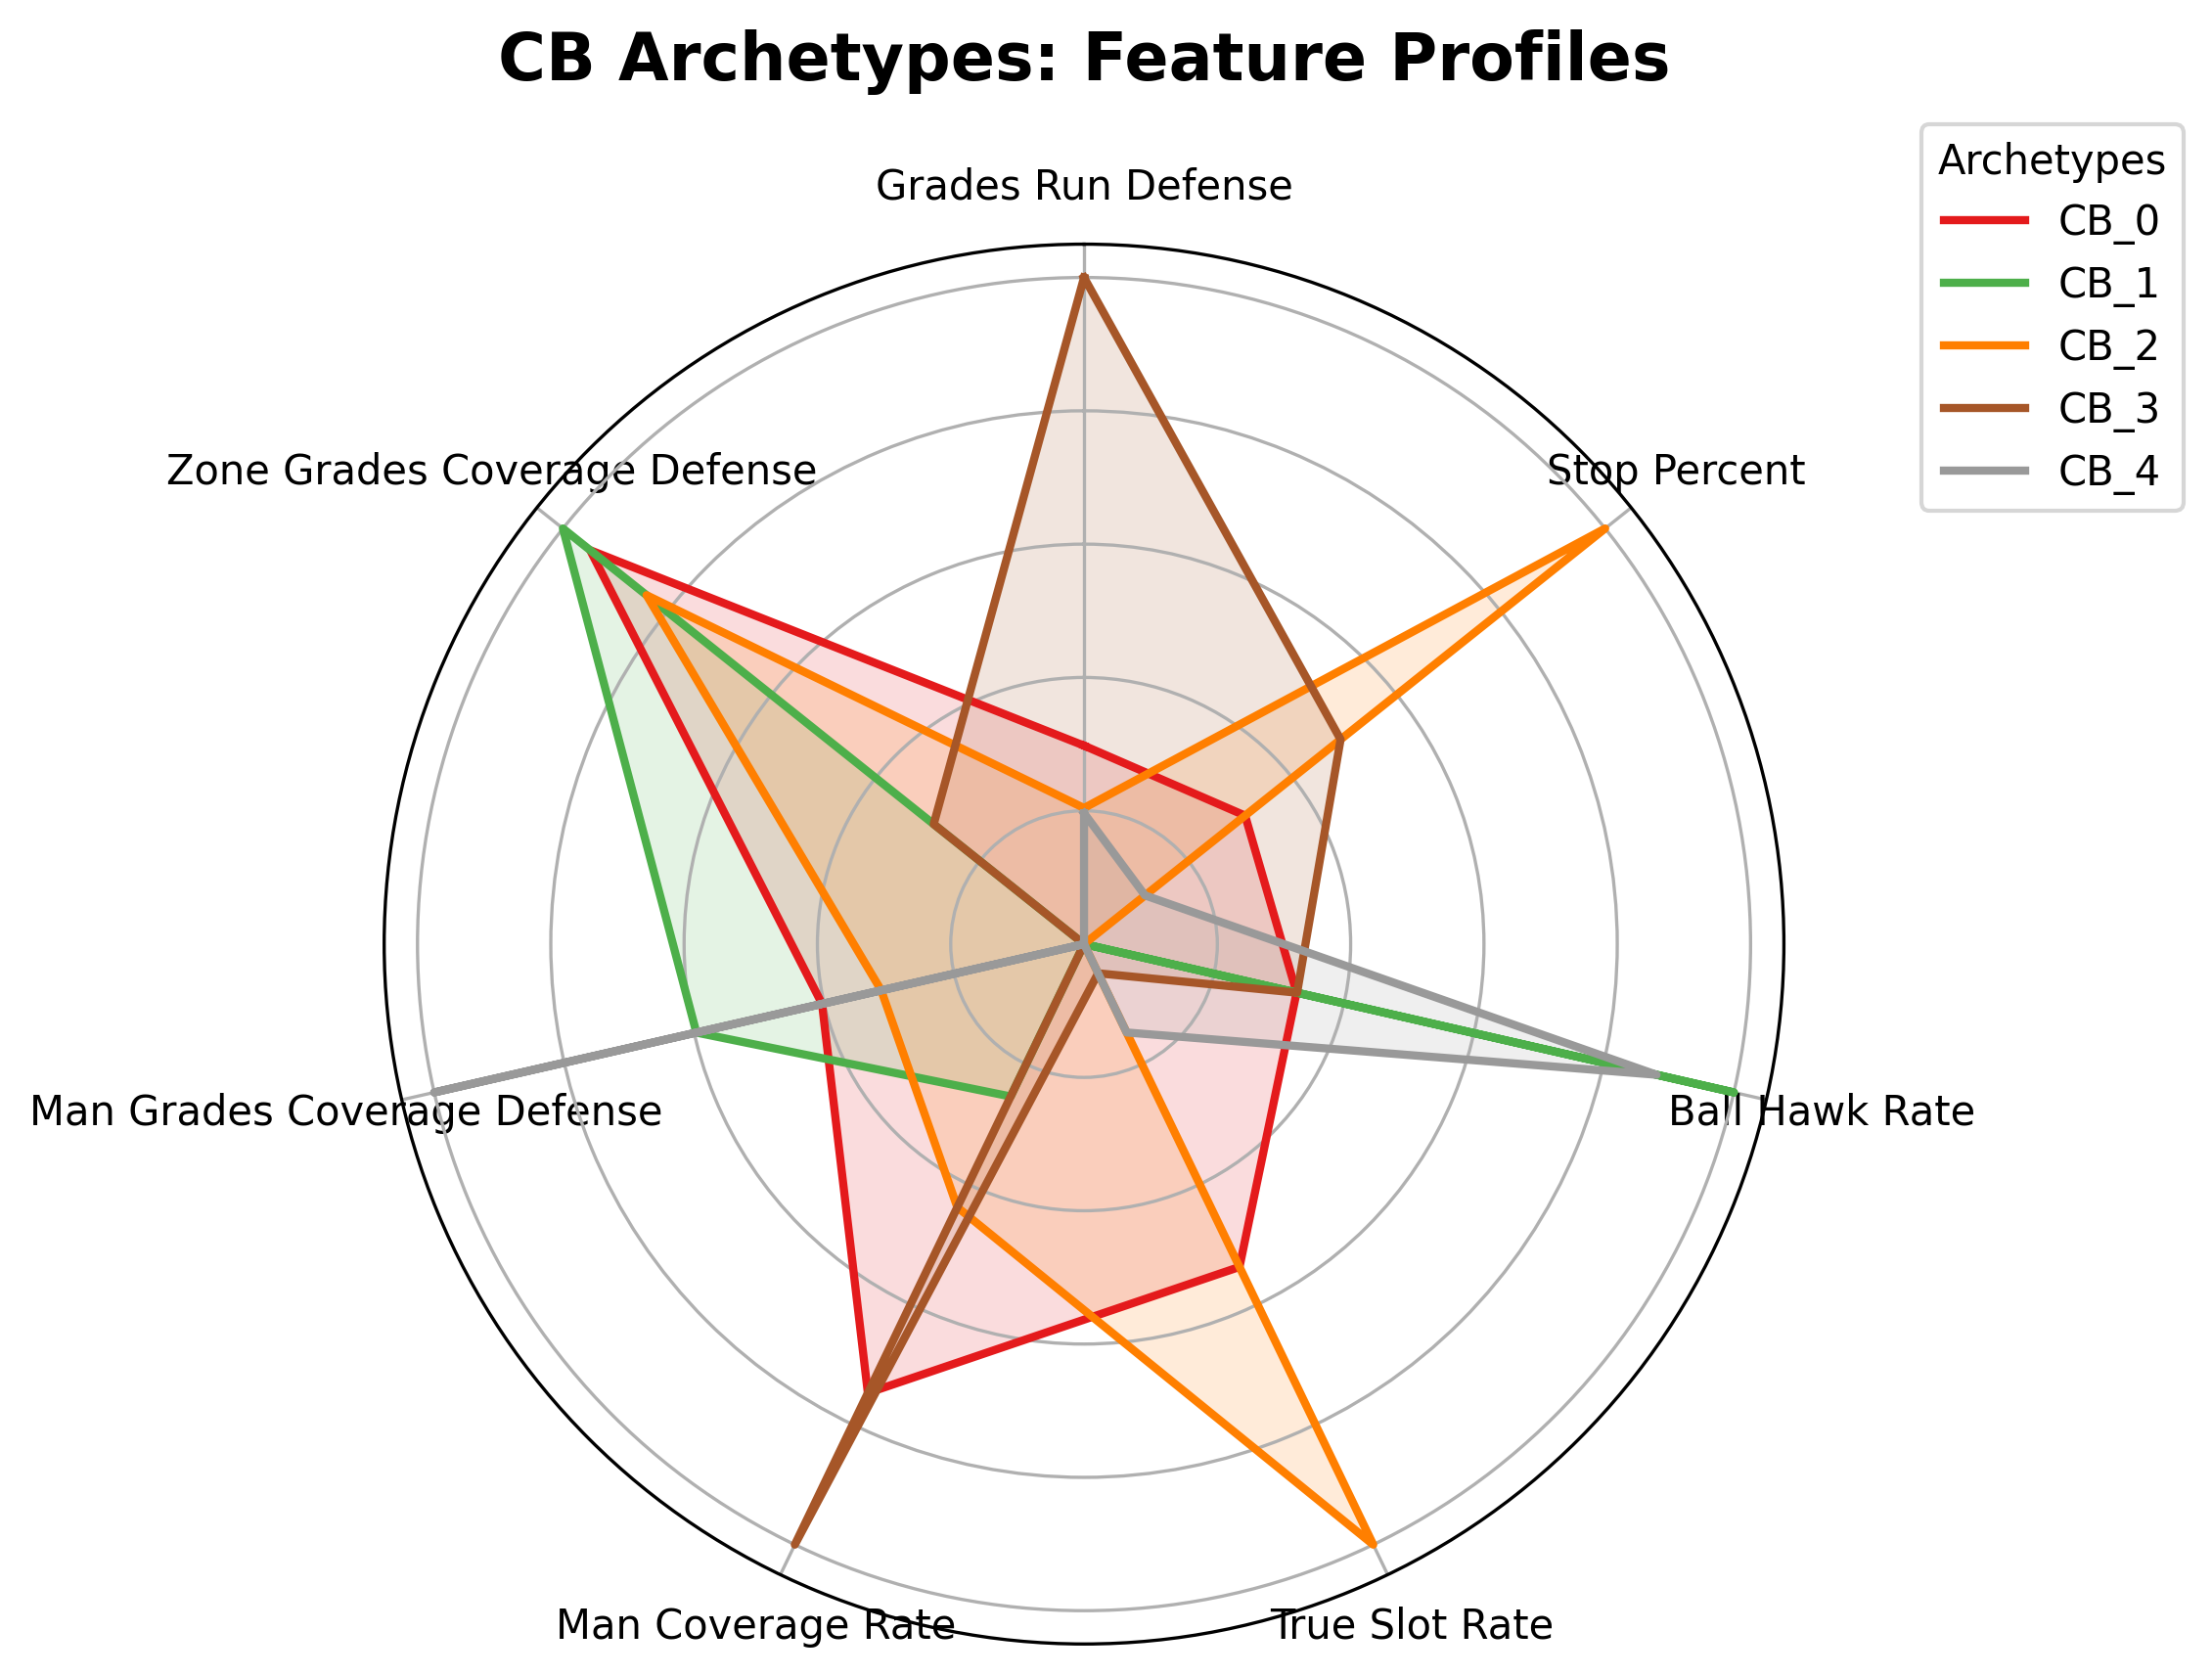

In [ ]:
from IPython.display import Image, display

# Display the mean feature values for Cornerback Clusters
print("--- Mean Feature Values for Cornerback Clusters ---")
display(grouped_stats_cb)

# Display the radar_CB.png image
print("\n--- Visualizing Cornerback Archetypes (radar_CB.png) ---")
display(Image(filename='radar_CB.png'))

## Analyze Cornerback (CB) Cluster Characteristics

Here are the mean feature values for each Cornerback cluster, followed by an analysis of each archetype:

| dominant_cluster | grades_run_defense | stop_percent | ball_hawk_rate | true_slot_rate | man_coverage_rate | man_grades_coverage_defense | zone_grades_coverage_defense |
|:---|:---|:---|:---|:---|:---|:---|:---|
| CB_0 | 61.589032 | 2.025806 | 0.089328 | 0.434232 | 0.324542 | 53.014839 | 65.990968 |
| CB_1 | 60.474439 | 1.281614 | 0.118576 | 0.027604 | 0.256030 | 54.258744 | 66.369955 |
| CB_2 | 61.238636 | 3.689205 | 0.075112 | 0.784004 | 0.281623 | 52.428977 | 65.206250 |
| CB_3 | 64.218382 | 2.466912 | 0.089363 | 0.064392 | 0.359583 | 50.421324 | 61.211029 |
| CB_4 | 61.209524 | 1.563492 | 0.113407 | 0.138950 | 0.220816 | 56.853968 | 59.119048 |

Here's an interpretation of each CB cluster:

*   **CB_0: "Versatile Zone-Dominant Slot/Outside Corner"**
    *   **Explanation**: This archetype shows solid zone coverage grades (`zone_grades_coverage_defense: 65.99`) and a relatively high `true_slot_rate` (`0.434`), indicating significant time spent in the slot, but also a balanced `man_coverage_rate` (`0.325`). They have moderate run defense (`61.59`) and a decent `ball_hawk_rate` (`0.089`). This suggests a versatile player capable of handling both inside and outside assignments, with a preference for zone schemes.
*   **CB_1: "Traditional Outside Zone Corner"**
    *   **Explanation**: This cluster is characterized by a very low `true_slot_rate` (`0.028`), implying they primarily play on the outside. They have strong zone coverage grades (`zone_grades_coverage_defense: 66.37`) and the highest `ball_hawk_rate` (`0.119`) among CBs, indicating good playmaking ability on the boundary, particularly in zone schemes. Their run defense (`60.47`) and `stop_percent` (`1.28`) are on the lower side.
*   **CB_2: "Primary Slot Run Stopper"**
    *   **Explanation**: Defined by an exceptionally high `true_slot_rate` (`0.784`), this archetype primarily operates from the slot. They also have the highest `stop_percent` (`3.69`) among CBs, indicating strong contributions in run defense from an inside alignment. Their `ball_hawk_rate` (`0.075`) is lower, and their coverage grades are moderate, suggesting their primary value is in slot coverage and run support rather than being a pure pass disruptor.
*   **CB_3: "Outside Man-Oriented Run Defender"**
    *   **Explanation**: This archetype exhibits the highest `grades_run_defense` (`64.22`) and a strong `man_coverage_rate` (`0.360`) but a very low `true_slot_rate` (`0.064`), indicating they are predominantly outside corners. Their `zone_grades_coverage_defense` (`61.21`) is the lowest among CBs, while `man_grades_coverage_defense` (`50.42`) is also lower. This profile suggests a player whose strength lies in run defense on the boundary and who is asked to play man coverage, possibly in a less demanding role.
*   **CB_4: "Deep Coverage Ball-Hawk"**
    *   **Explanation**: This cluster shows the highest `man_grades_coverage_defense` (`56.85`) among CBs, indicating effectiveness in man coverage, along with a high `ball_hawk_rate` (`0.113`), suggesting good pass disruption. Their `true_slot_rate` (`0.139`) is low, meaning they mostly play outside. However, their `zone_grades_coverage_defense` (`59.12`) is the lowest, and their `stop_percent` (`1.56`) and `grades_run_defense` (`61.21`) are moderate, indicating a focus on pure pass coverage, likely in a deep or boundary role where they can make plays on the ball.

--- Mean Feature Values for Safety Clusters ---


,grades_run_defense,true_slot_rate,stop_percent,ball_hawk_rate,man_grades_coverage_defense,zone_grades_coverage_defense,fs_rate,box_rate
dominant_cluster,,,,,,,,
S_0,65.030102,0.210250,3.189286,0.094680,61.447449,59.864796,0.353268,0.411307
S_1,57.137500,0.109949,2.681250,0.094255,56.743750,56.718750,0.598040,0.199778
S_2,66.400000,0.115212,3.003264,0.150132,62.326706,62.641246,0.565502,0.309450
S_3,65.321951,0.358786,4.728049,0.084937,59.113415,63.379268,0.240869,0.353766
S_4,65.083000,0.069580,1.614000,0.269038,61.010000,62.299000,0.759141,0.165660



--- Visualizing Safety Archetypes (radar_S.png) ---


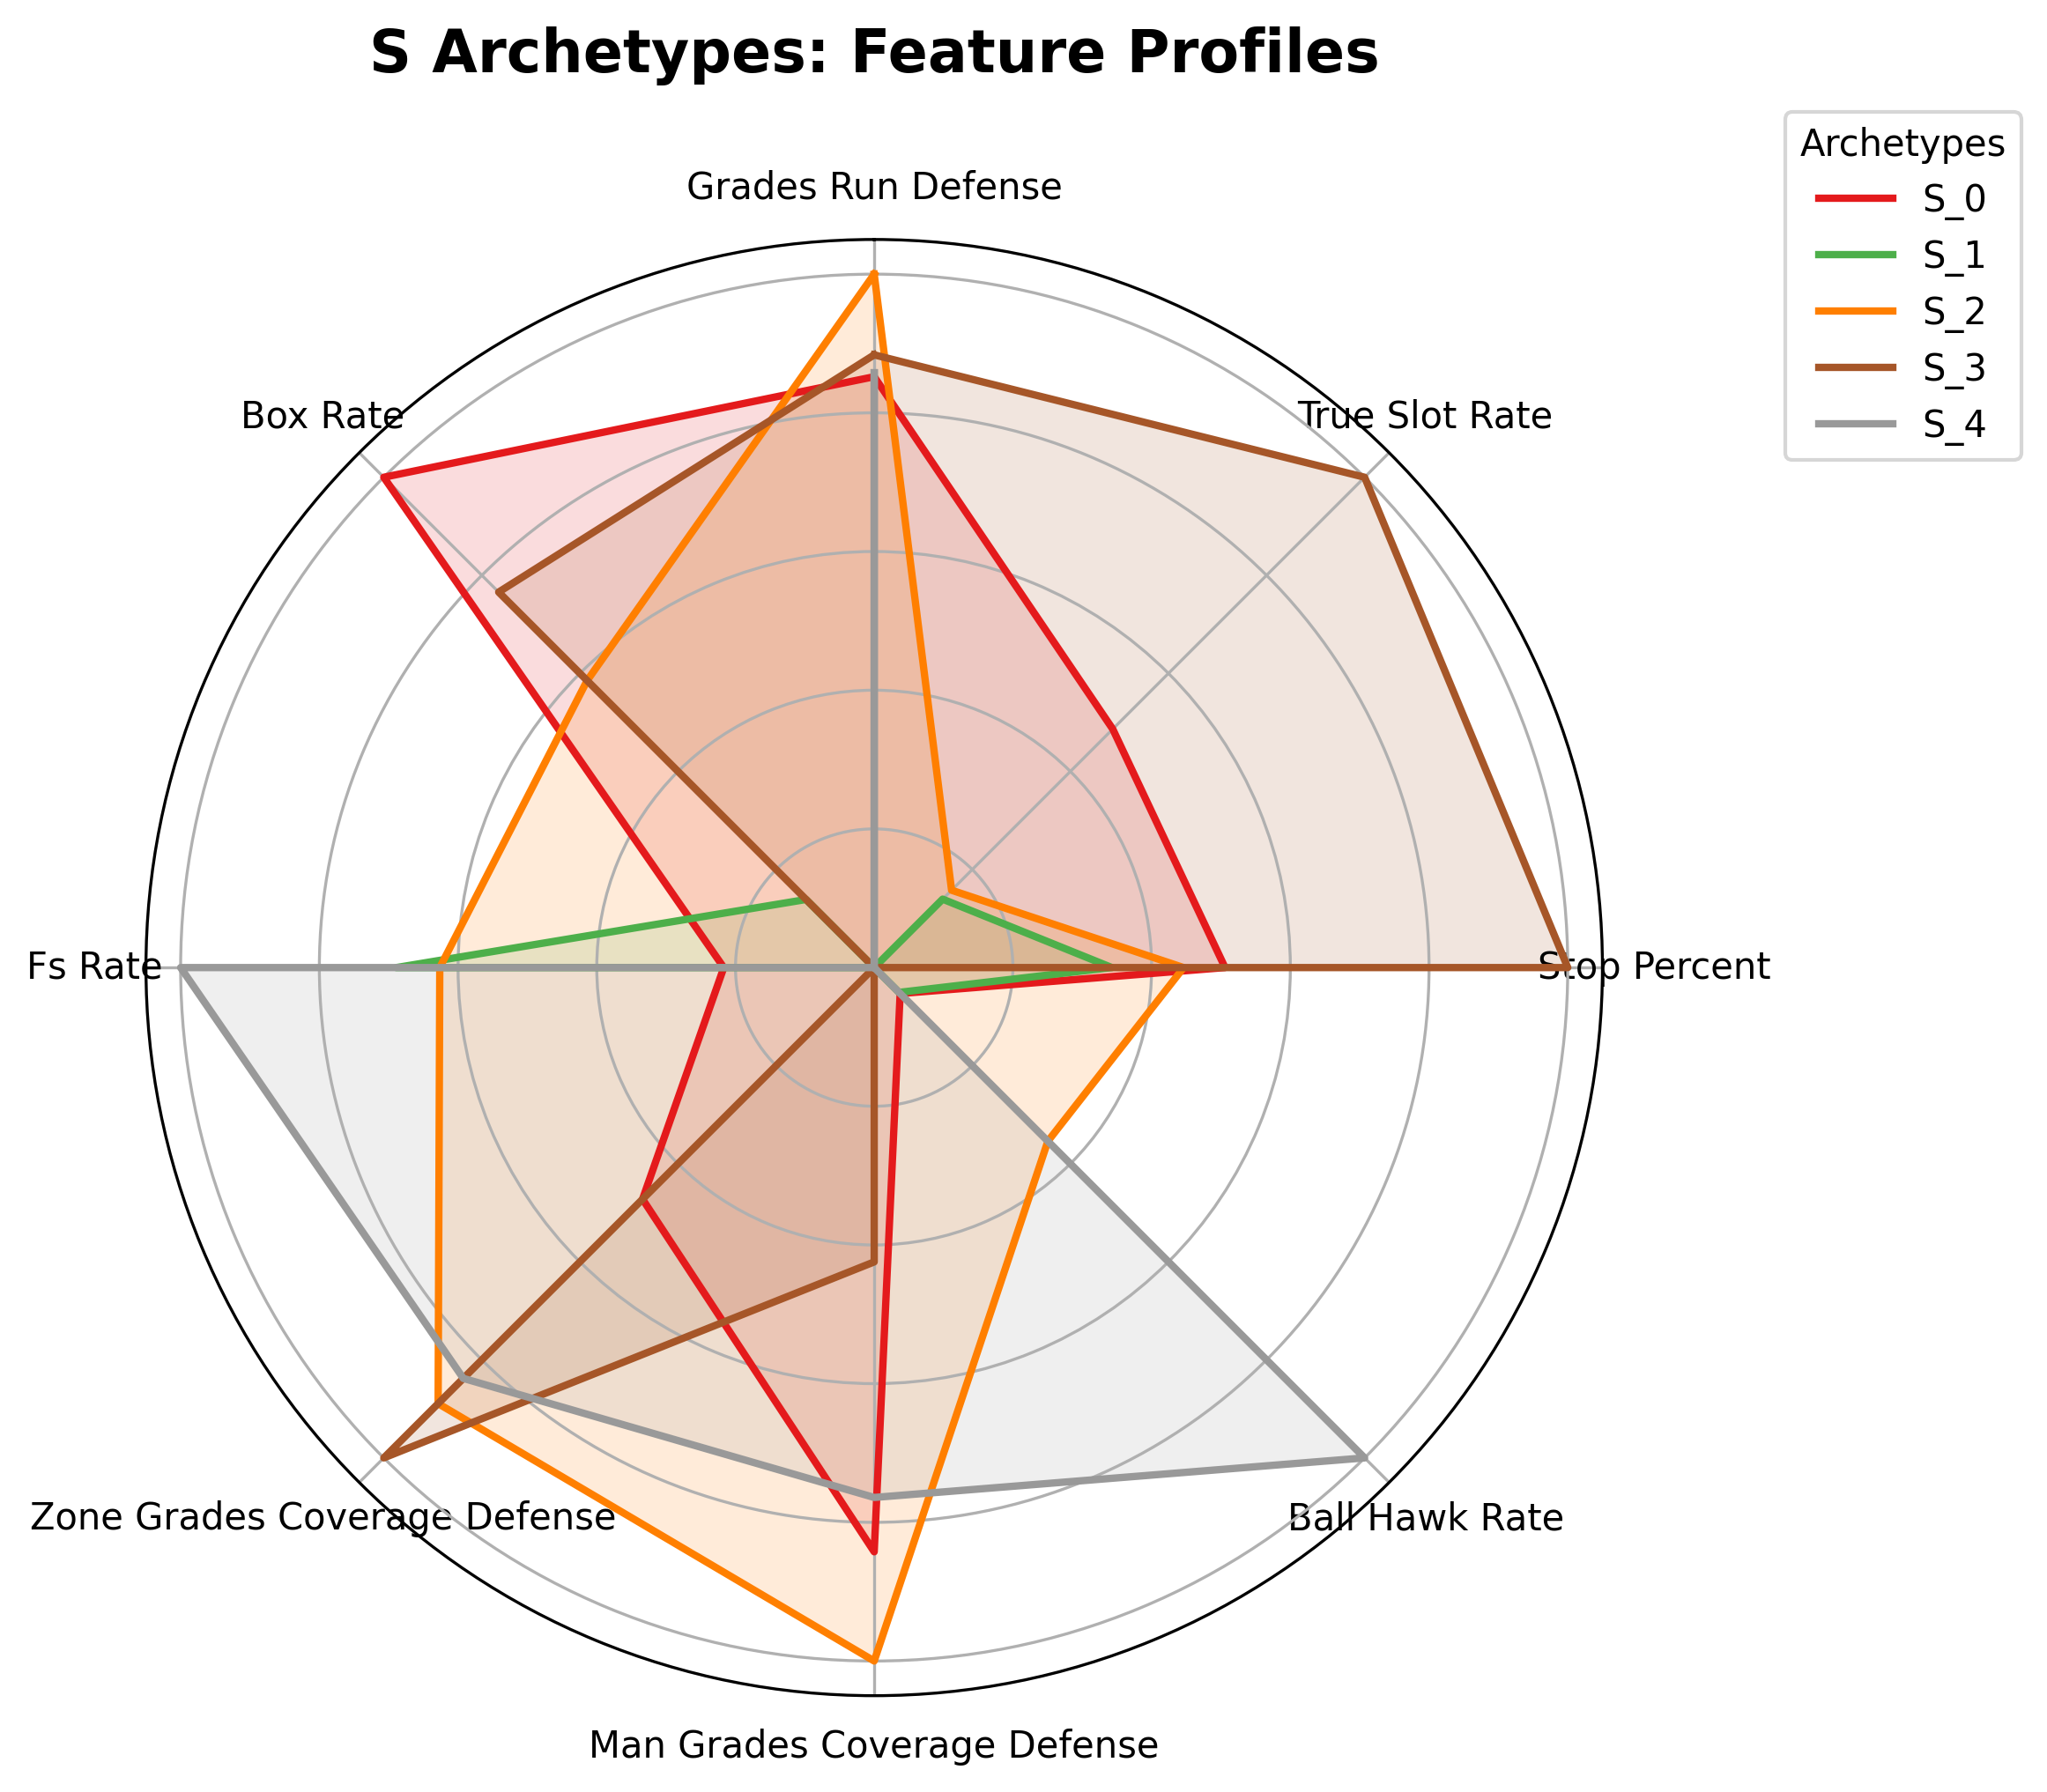

In [ ]:
from IPython.display import Image, display

# Display the mean feature values for Safety Clusters
print("--- Mean Feature Values for Safety Clusters ---")
display(grouped_stats_s)

# Display the radar_S.png image
print("\n--- Visualizing Safety Archetypes (radar_S.png) ---")
display(Image(filename='radar_S.png'))

### Analyze Safety (S) Cluster Characteristics

Here are the mean feature values for each Safety cluster, followed by an analysis of each archetype:

| dominant_cluster | grades_run_defense | true_slot_rate | stop_percent | ball_hawk_rate | man_grades_coverage_defense | zone_grades_coverage_defense | fs_rate | box_rate |
|:---|:---|:---|:---|:---|:---|:---|:---|:---|
| S_0 | 65.030102 | 0.210250 | 3.189286 | 0.094680 | 61.447449 | 59.864796 | 0.353268 | 0.411307 |
| S_1 | 57.137500 | 0.109949 | 2.681250 | 0.094255 | 56.743750 | 56.718750 | 0.598040 | 0.199778 |
| S_2 | 66.400000 | 0.115212 | 3.003264 | 0.150132 | 62.326706 | 62.641246 | 0.565502 | 0.309450 |
| S_3 | 65.321951 | 0.358786 | 4.728049 | 0.084937 | 59.113415 | 63.379268 | 0.240869 | 0.353766 |
| S_4 | 65.083000 | 0.069580 | 1.614000 | 0.269038 | 61.010000 | 62.299000 | 0.759141 | 0.165660 |

Here's an interpretation of each S cluster:

*   **S_0: "Versatile Box-to-Deep Hybrid"**
    *   **Explanation**: This archetype demonstrates a balanced profile, capable of playing closer to the line of scrimmage with a good `box_rate` (0.411) and solid `grades_run_defense` (65.03), while also contributing to deep coverage with a decent `fs_rate` (0.353). They show good coverage grades in both man and zone, and a moderate `ball_hawk_rate` (0.095). This suggests a flexible safety who can adapt to various defensive schemes.
*   **S_1: "Coverage-Oriented Free Safety"**
    *   **Explanation**: Characterized by a high `fs_rate` (0.598) and a low `box_rate` (0.200), these safeties primarily operate in deep coverage. Their `grades_run_defense` (57.14) is the lowest among safeties, and their `stop_percent` (2.68) is moderate, indicating less involvement in run support. They focus on preventing big plays downfield with decent coverage grades and ball-hawking ability (0.094).
*   **S_2: "Dynamic Ball-Hawking Deep Safety"**
    *   **Explanation**: This cluster exhibits the highest `ball_hawk_rate` (0.150) and strong coverage grades in both man (62.33) and zone (62.64), indicating excellent playmaking ability in the passing game. They have a high `fs_rate` (0.565), suggesting a primary role in deep coverage, but also a notable `box_rate` (0.309) showing some versatility to play closer to the line. Their `grades_run_defense` (66.40) is robust.
*   **S_3: "Run-Stopping Slot/Box Safety"**
    *   **Explanation**: This archetype excels in run defense, boasting the highest `stop_percent` (4.73) and a high `box_rate` (0.354), indicating strong contributions near the line of scrimmage. They also have a high `true_slot_rate` (0.359), suggesting frequent alignment in the slot. Their `fs_rate` (0.241) is lower, emphasizing their role closer to the action. Their `ball_hawk_rate` (0.085) and coverage grades are more modest, aligning with a primary focus on run support and short-area coverage.
*   **S_4: "Elite Over-the-Top Ballhawk"**
    *   **Explanation**: Defined by an exceptionally high `fs_rate` (0.759) and the highest `ball_hawk_rate` (0.269) among safeties, this cluster represents players whose primary role is to patrol the deep middle and make game-changing plays on the ball. Their `box_rate` (0.166) and `true_slot_rate` (0.070) are very low, confirming their specialized deep coverage role. While their `grades_run_defense` (65.08) is solid, their lowest `stop_percent` (1.61) suggests they are less involved in direct run stops, prioritizing interception and pass break-up opportunities.

--- Mean Feature Values for Linebacker Clusters ---


,grades_run_defense,grades_coverage_defense,stop_percent,pressure_rate
dominant_cluster,,,,
LB_0,64.570435,40.986957,7.620000,0.163880
LB_1,46.727165,56.996850,5.582283,0.178009
LB_2,72.393069,65.484818,8.128383,0.169614
LB_3,66.255814,49.802326,6.288372,0.432866



--- Visualizing Linebacker Archetypes (radar_LB.png) ---


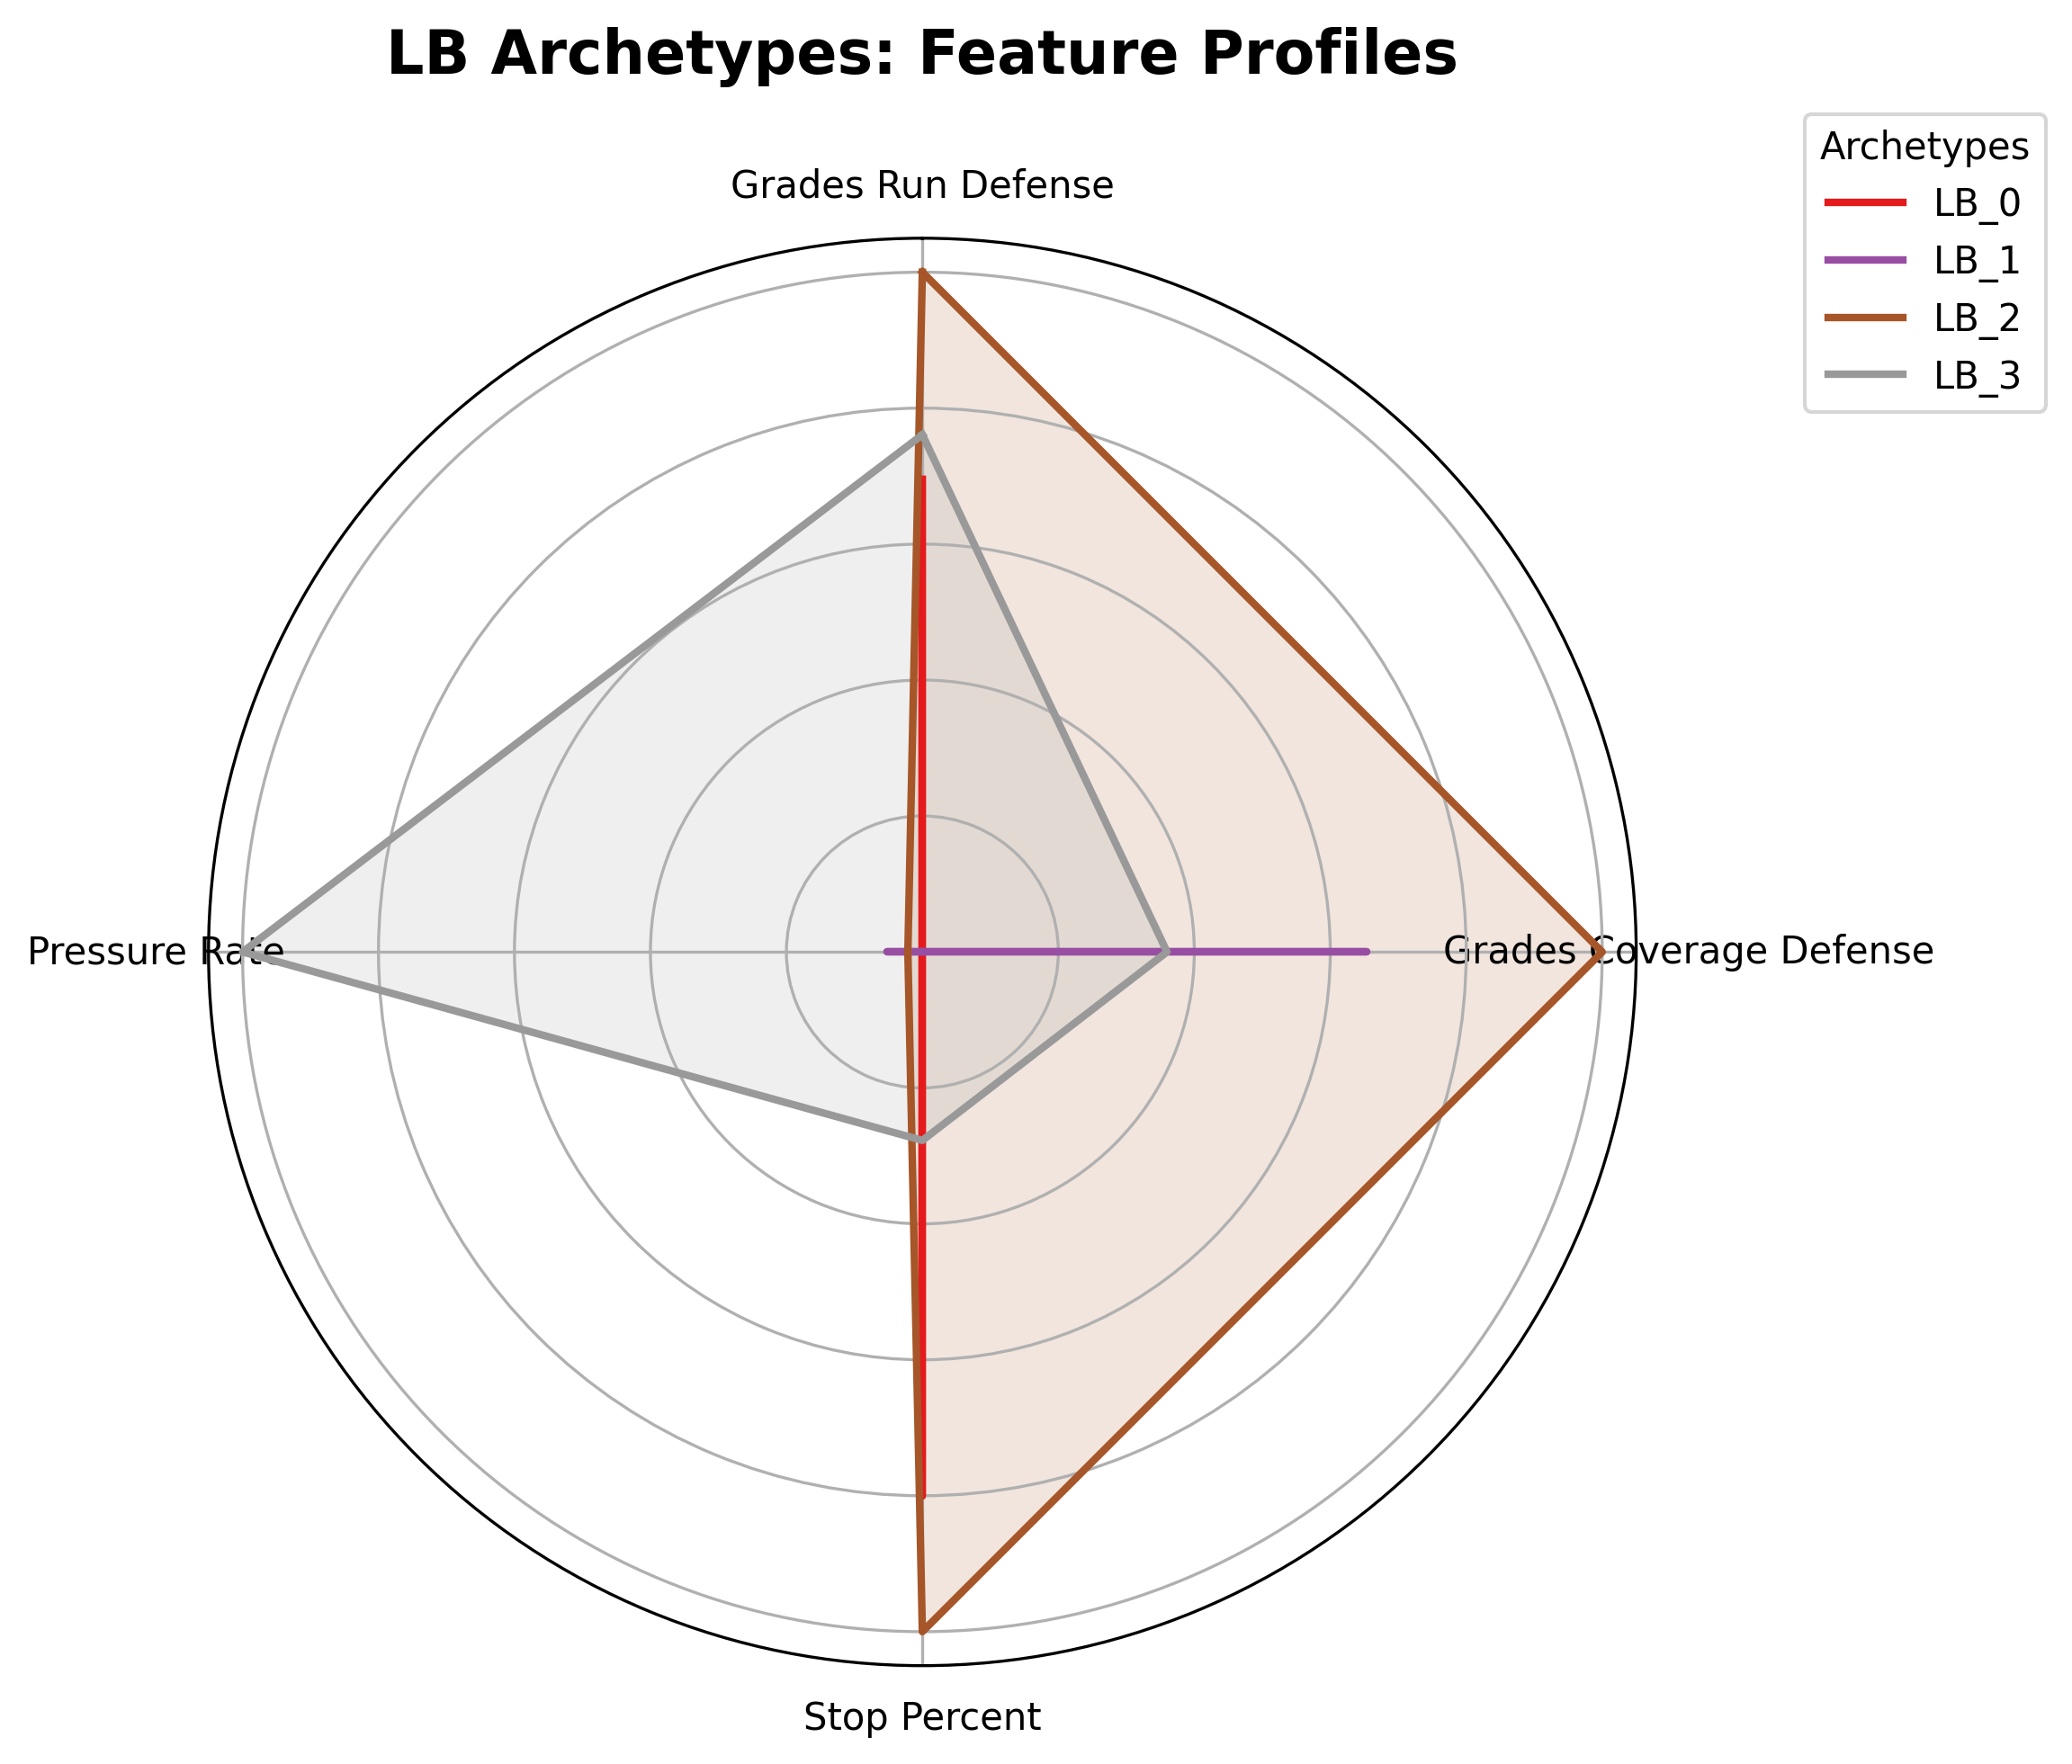

In [ ]:
from IPython.display import Image, display

# Display the mean feature values for Linebacker Clusters
print("--- Mean Feature Values for Linebacker Clusters ---")
display(grouped_stats_lb)

# Display the radar_LB.png image
print("\n--- Visualizing Linebacker Archetypes (radar_LB.png) ---")
display(Image(filename='radar_LB.png'))

### Analyze Linebacker (LB) Cluster Characteristics

Here are the mean feature values for each Linebacker cluster, followed by an analysis of each archetype:

| dominant_cluster | grades_run_defense | grades_coverage_defense | stop_percent | pressure_rate |
|:---|:---|:---|:---|:---|
| LB_0 | 64.570435 | 40.986957 | 7.620000 | 0.163880 |
| LB_1 | 46.727165 | 56.996850 | 5.582283 | 0.178009 |
| LB_2 | 72.393069 | 65.484818 | 8.128383 | 0.169614 |
| LB_3 | 66.255814 | 49.802326 | 6.288372 | 0.432866 |

Here's an interpretation of each LB cluster:

*   **LB_0: "Early Down Run Stopper (Coverage Weakness)"**
    *   **Explanation**: This archetype excels in run defense with a good `grades_run_defense` (`64.57`) and a very high `stop_percent` (`7.62`), indicating they are effective at stopping runs for short gains. However, their `grades_coverage_defense` (`40.99`) is the lowest among all LBs, suggesting they are a liability in pass coverage and are likely subbed out on obvious passing downs. Their `pressure_rate` (`0.164`) is moderate.
*   **LB_1: "Coverage-Focused Linebacker (Run/Pressure Weakness)"**
    *   **Explanation**: These linebackers prioritize coverage, as indicated by their significantly higher `grades_coverage_defense` (`57.00`) compared to LB_0. They have the lowest `grades_run_defense` (`46.73`) and `stop_percent` (`5.58`), suggesting less involvement in run defense. Their `pressure_rate` (`0.178`) is also moderate, indicating their primary role is to drop into coverage rather than consistently rushing the passer or stuffing runs.
*   **LB_2: "Elite All-Around Linebacker"**
    *   **Explanation**: This cluster represents the most balanced and effective linebackers, with outstanding `grades_run_defense` (`72.39`), the highest `grades_coverage_defense` (`65.48`), and the highest `stop_percent` (`8.13`). Their `pressure_rate` (`0.170`) is also solid, showcasing a player who can contribute effectively in all aspects of defense. These players are true three-down linebackers capable of excelling against the run, in coverage, and generating some pressure.
*   **LB_3: "Blitzing & Run-Support Linebacker"**
    *   **Explanation**: Characterized by the highest `pressure_rate` (`0.433`), this archetype is primarily used to rush the passer. They have strong `grades_run_defense` (`66.26`) and a good `stop_percent` (`6.29`), showing competency against the run. Their `grades_coverage_defense` (`49.80`) is better than the run-stuffing LB_0, making them versatile enough to blitz and play some coverage, but their primary impact comes from pressuring the quarterback.

--- Mean Feature Values for Edge Defender Clusters ---


,grades_pass_rush_defense,grades_run_defense,pass_rush_win_rate,pressure_rate,stop_percent,inside_rate
dominant_cluster,,,,,,
ED_0,61.130400,58.494400,8.973600,0.091454,6.292800,0.140016
ED_1,65.224906,62.429811,10.738113,0.108494,6.023019,0.000000
ED_2,60.892742,61.174597,9.457258,0.095446,5.580242,0.006505
ED_3,70.543277,62.182773,12.426471,0.109094,6.754622,0.021800



--- Visualizing Edge Defender Archetypes (radar_ED.png) ---


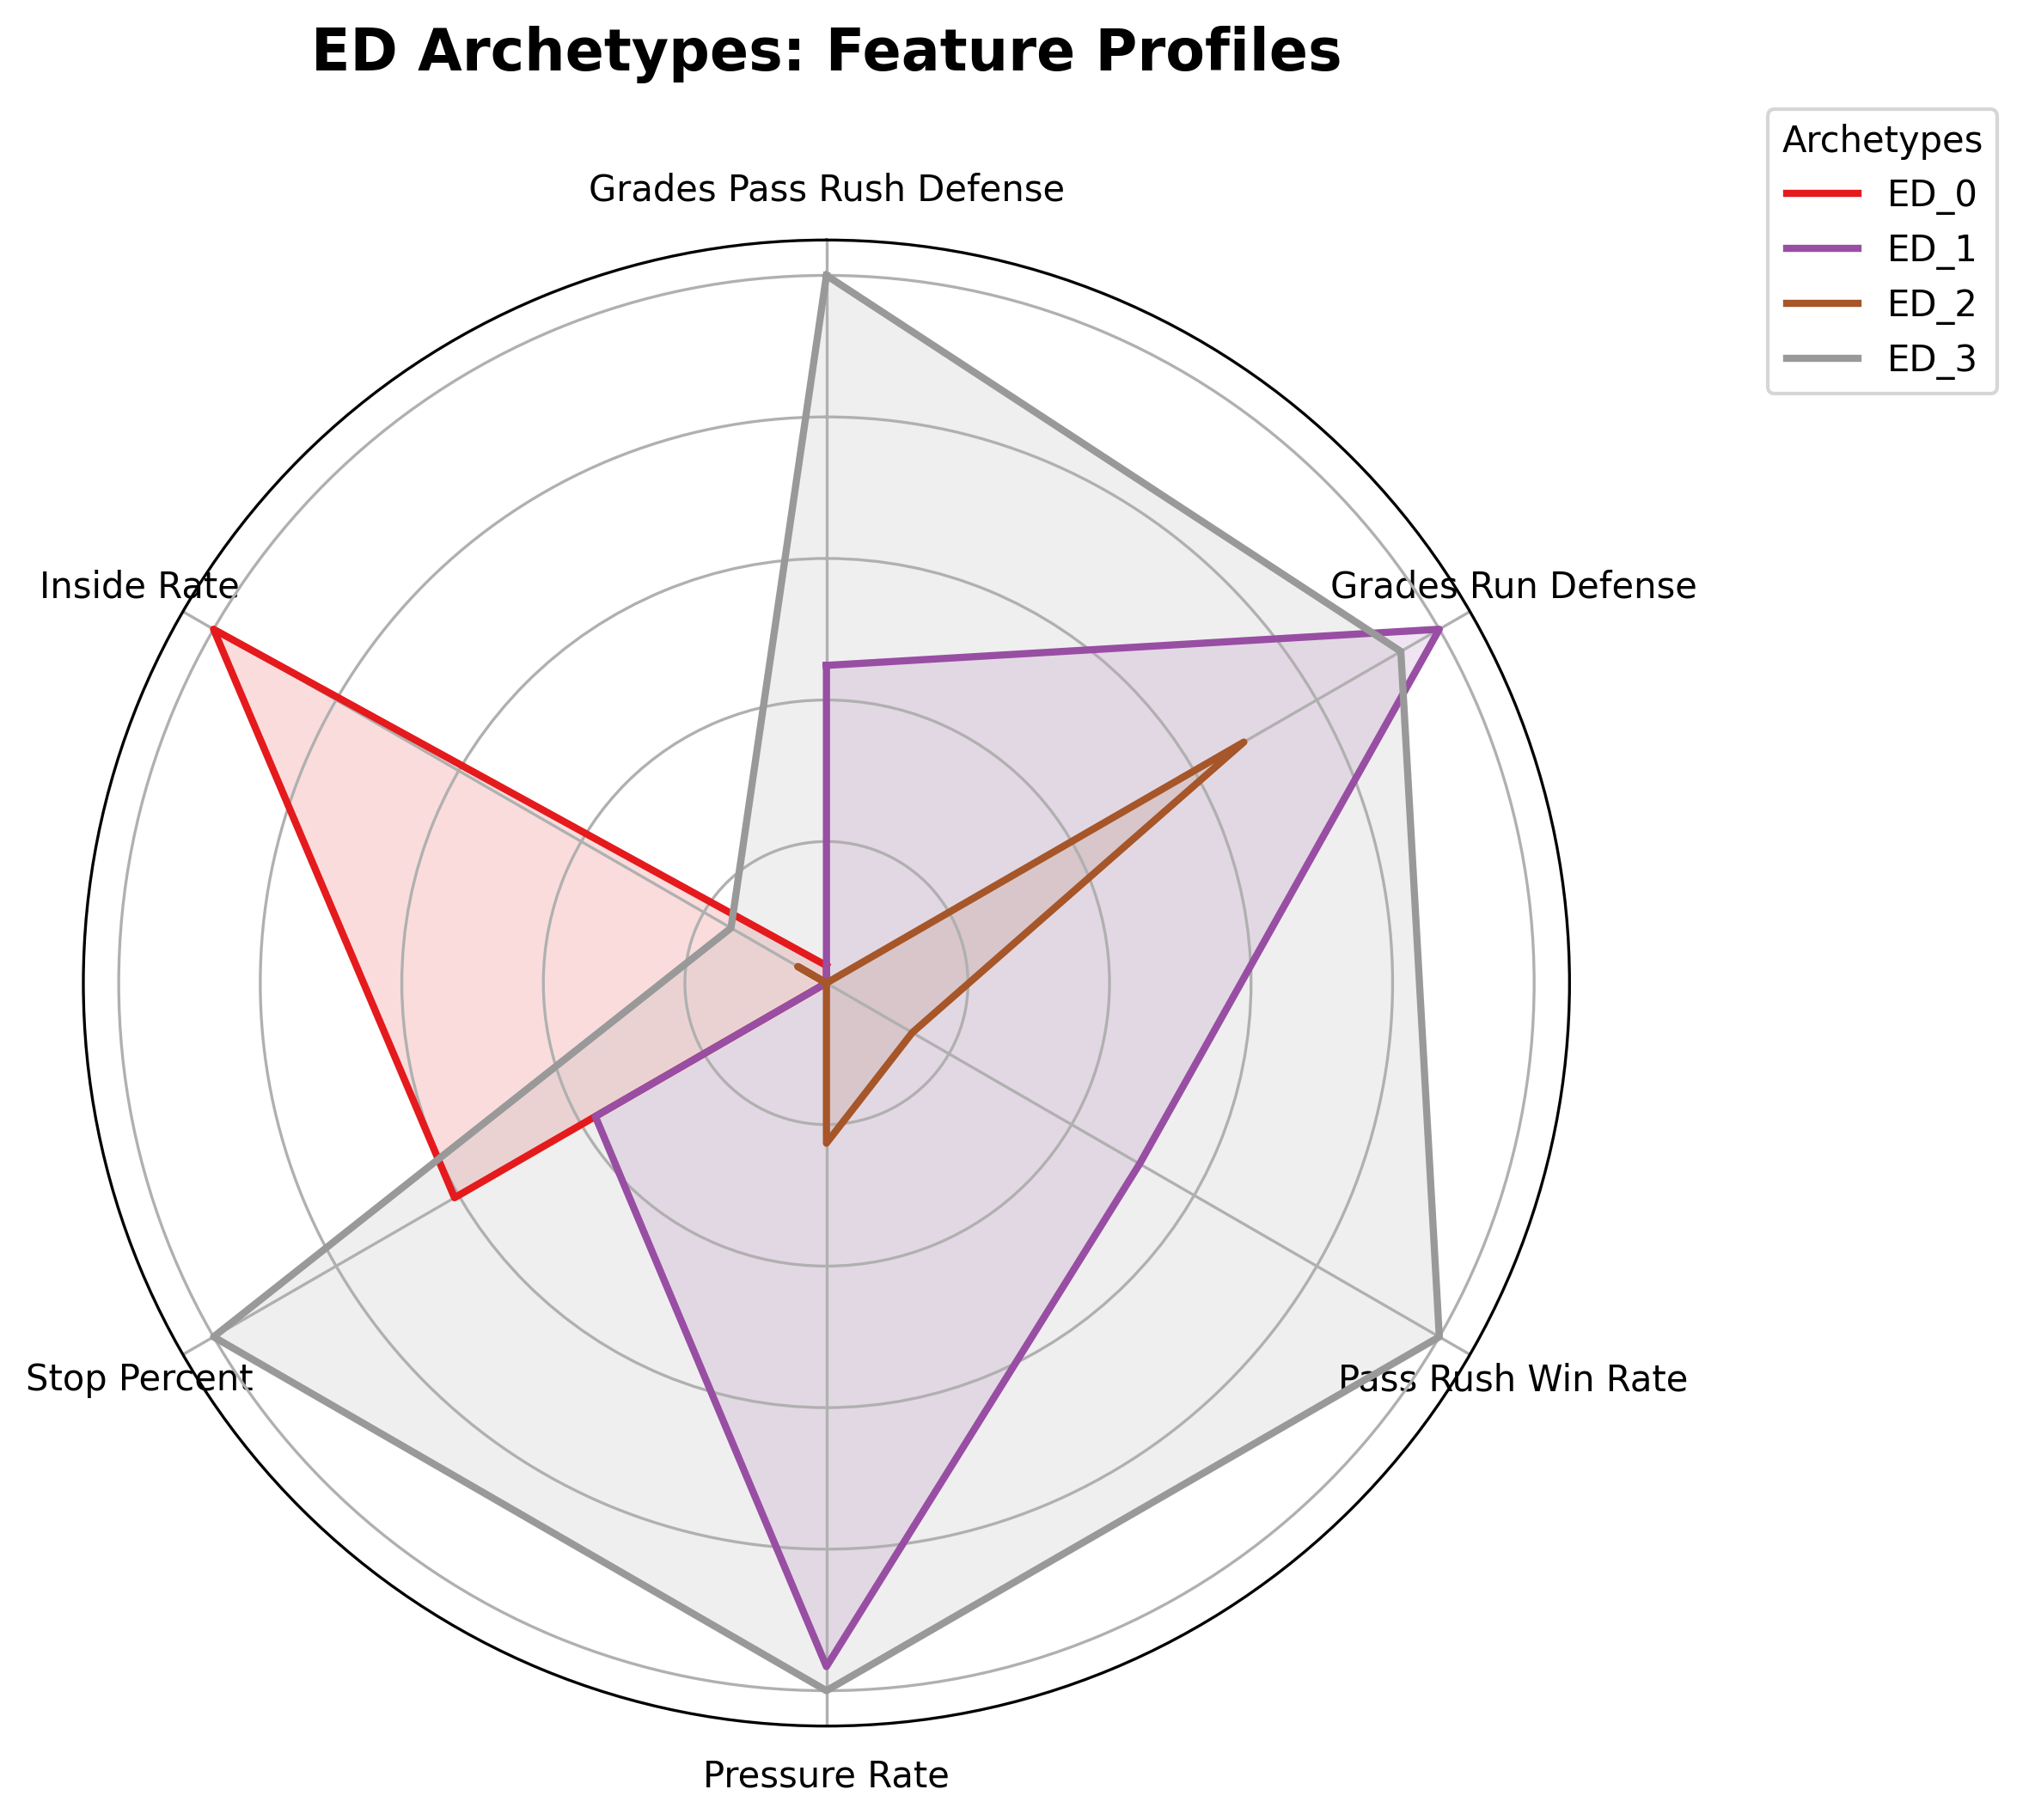

In [ ]:
from IPython.display import Image, display

# Display the mean feature values for Edge Defender Clusters
print("--- Mean Feature Values for Edge Defender Clusters ---")
display(grouped_stats_ed)

# Display the radar_ED.png image
print("\n--- Visualizing Edge Defender Archetypes (radar_ED.png) ---")
display(Image(filename='radar_ED.png'))

### Analyze Edge Defender (ED) Cluster Characteristics

Here are the mean feature values for each Edge Defender cluster, followed by an analysis of each archetype:

| dominant_cluster | grades_pass_rush_defense | grades_run_defense | pass_rush_win_rate | pressure_rate | stop_percent | inside_rate |
|:---|:---|:---|:---|:---|:---|:---|
| ED_0 | 61.130400 | 58.494400 | 8.973600 | 0.091454 | 6.292800 | 0.140016 |
| ED_1 | 65.224906 | 62.429811 | 10.738113 | 0.108494 | 6.023019 | 0.000000 |
| ED_2 | 60.892742 | 61.174597 | 9.457258 | 0.095446 | 5.580242 | 0.006505 |
| ED_3 | 70.543277 | 62.182773 | 12.426471 | 0.109094 | 6.754622 | 0.021800 |

Here's an interpretation of each ED cluster:

*   **ED_0: "Hybrid Interior-Edge Rotational"**
    *   **Explanation**: This archetype is characterized by the highest `inside_rate` (`0.140`), suggesting they spend significant time rushing from inside gaps or playing closer to the interior. Their `grades_pass_rush_defense` (`61.13`) and `grades_run_defense` (`58.49`) are moderate, indicating a versatile but not elite player often used in rotation rather than as a primary edge setter or pass rusher.
*   **ED_1: "Balanced Edge Defender"**
    *   **Explanation**: Characterized by an `inside_rate` of `0.000`, this archetype exclusively plays on the edge. They exhibit good all-around pass-rush metrics (`grades_pass_rush_defense: 65.22`, `pass_rush_win_rate: 10.74`, `pressure_rate: 0.108`) and solid `grades_run_defense` (`62.43`). This suggests a reliable edge presence capable of contributing effectively against both the run and the pass, without a specific interior alignment tendency.
*   **ED_2: "Run-Focused Edge Defender"**
    *   **Explanation**: This cluster shows the lowest `grades_pass_rush_defense` (`60.89`) and `stop_percent` (`5.58`) among EDs, indicating less impact in pass rush and run stops compared to other archetypes. However, their `grades_run_defense` (`61.17`) is decent, and their `inside_rate` is very low (`0.006`), confirming an edge role. This profile suggests a player whose primary role is to set the edge against the run, relying less on generating consistent pass rush disruption.
*   **ED_3: "Elite Dual-Threat Edge Rusher"**
    *   **Explanation**: This archetype stands out with the highest metrics across the board: `grades_pass_rush_defense` (`70.54`), `pass_rush_win_rate` (`12.43`), `pressure_rate` (`0.109`), and `stop_percent` (`6.75`). This indicates an elite player excelling at both rushing the passer and contributing significantly to run defense. Their `inside_rate` is low (`0.022`), confirming their primary role as an edge player but with occasional versatility to align inside for specific schemes, making them a true dual-threat defensive weapon.

--- Mean Feature Values for Defensive Interior Clusters ---


,grades_pass_rush_defense,grades_run_defense,pass_rush_win_rate,a_gap_rate,b_gap_rate,outside_rate
dominant_cluster,,,,,,
DI_0,59.656296,54.905926,5.442222,0.252461,0.700432,0.000000
DI_1,65.990798,54.275460,8.998160,0.069764,0.709586,0.011540
DI_2,61.635106,56.026596,6.679787,0.253431,0.587524,0.028749
DI_3,64.359091,55.796465,8.997475,0.028335,0.498346,0.126054



--- Visualizing Defensive Interior Archetypes (radar_DI.png) ---


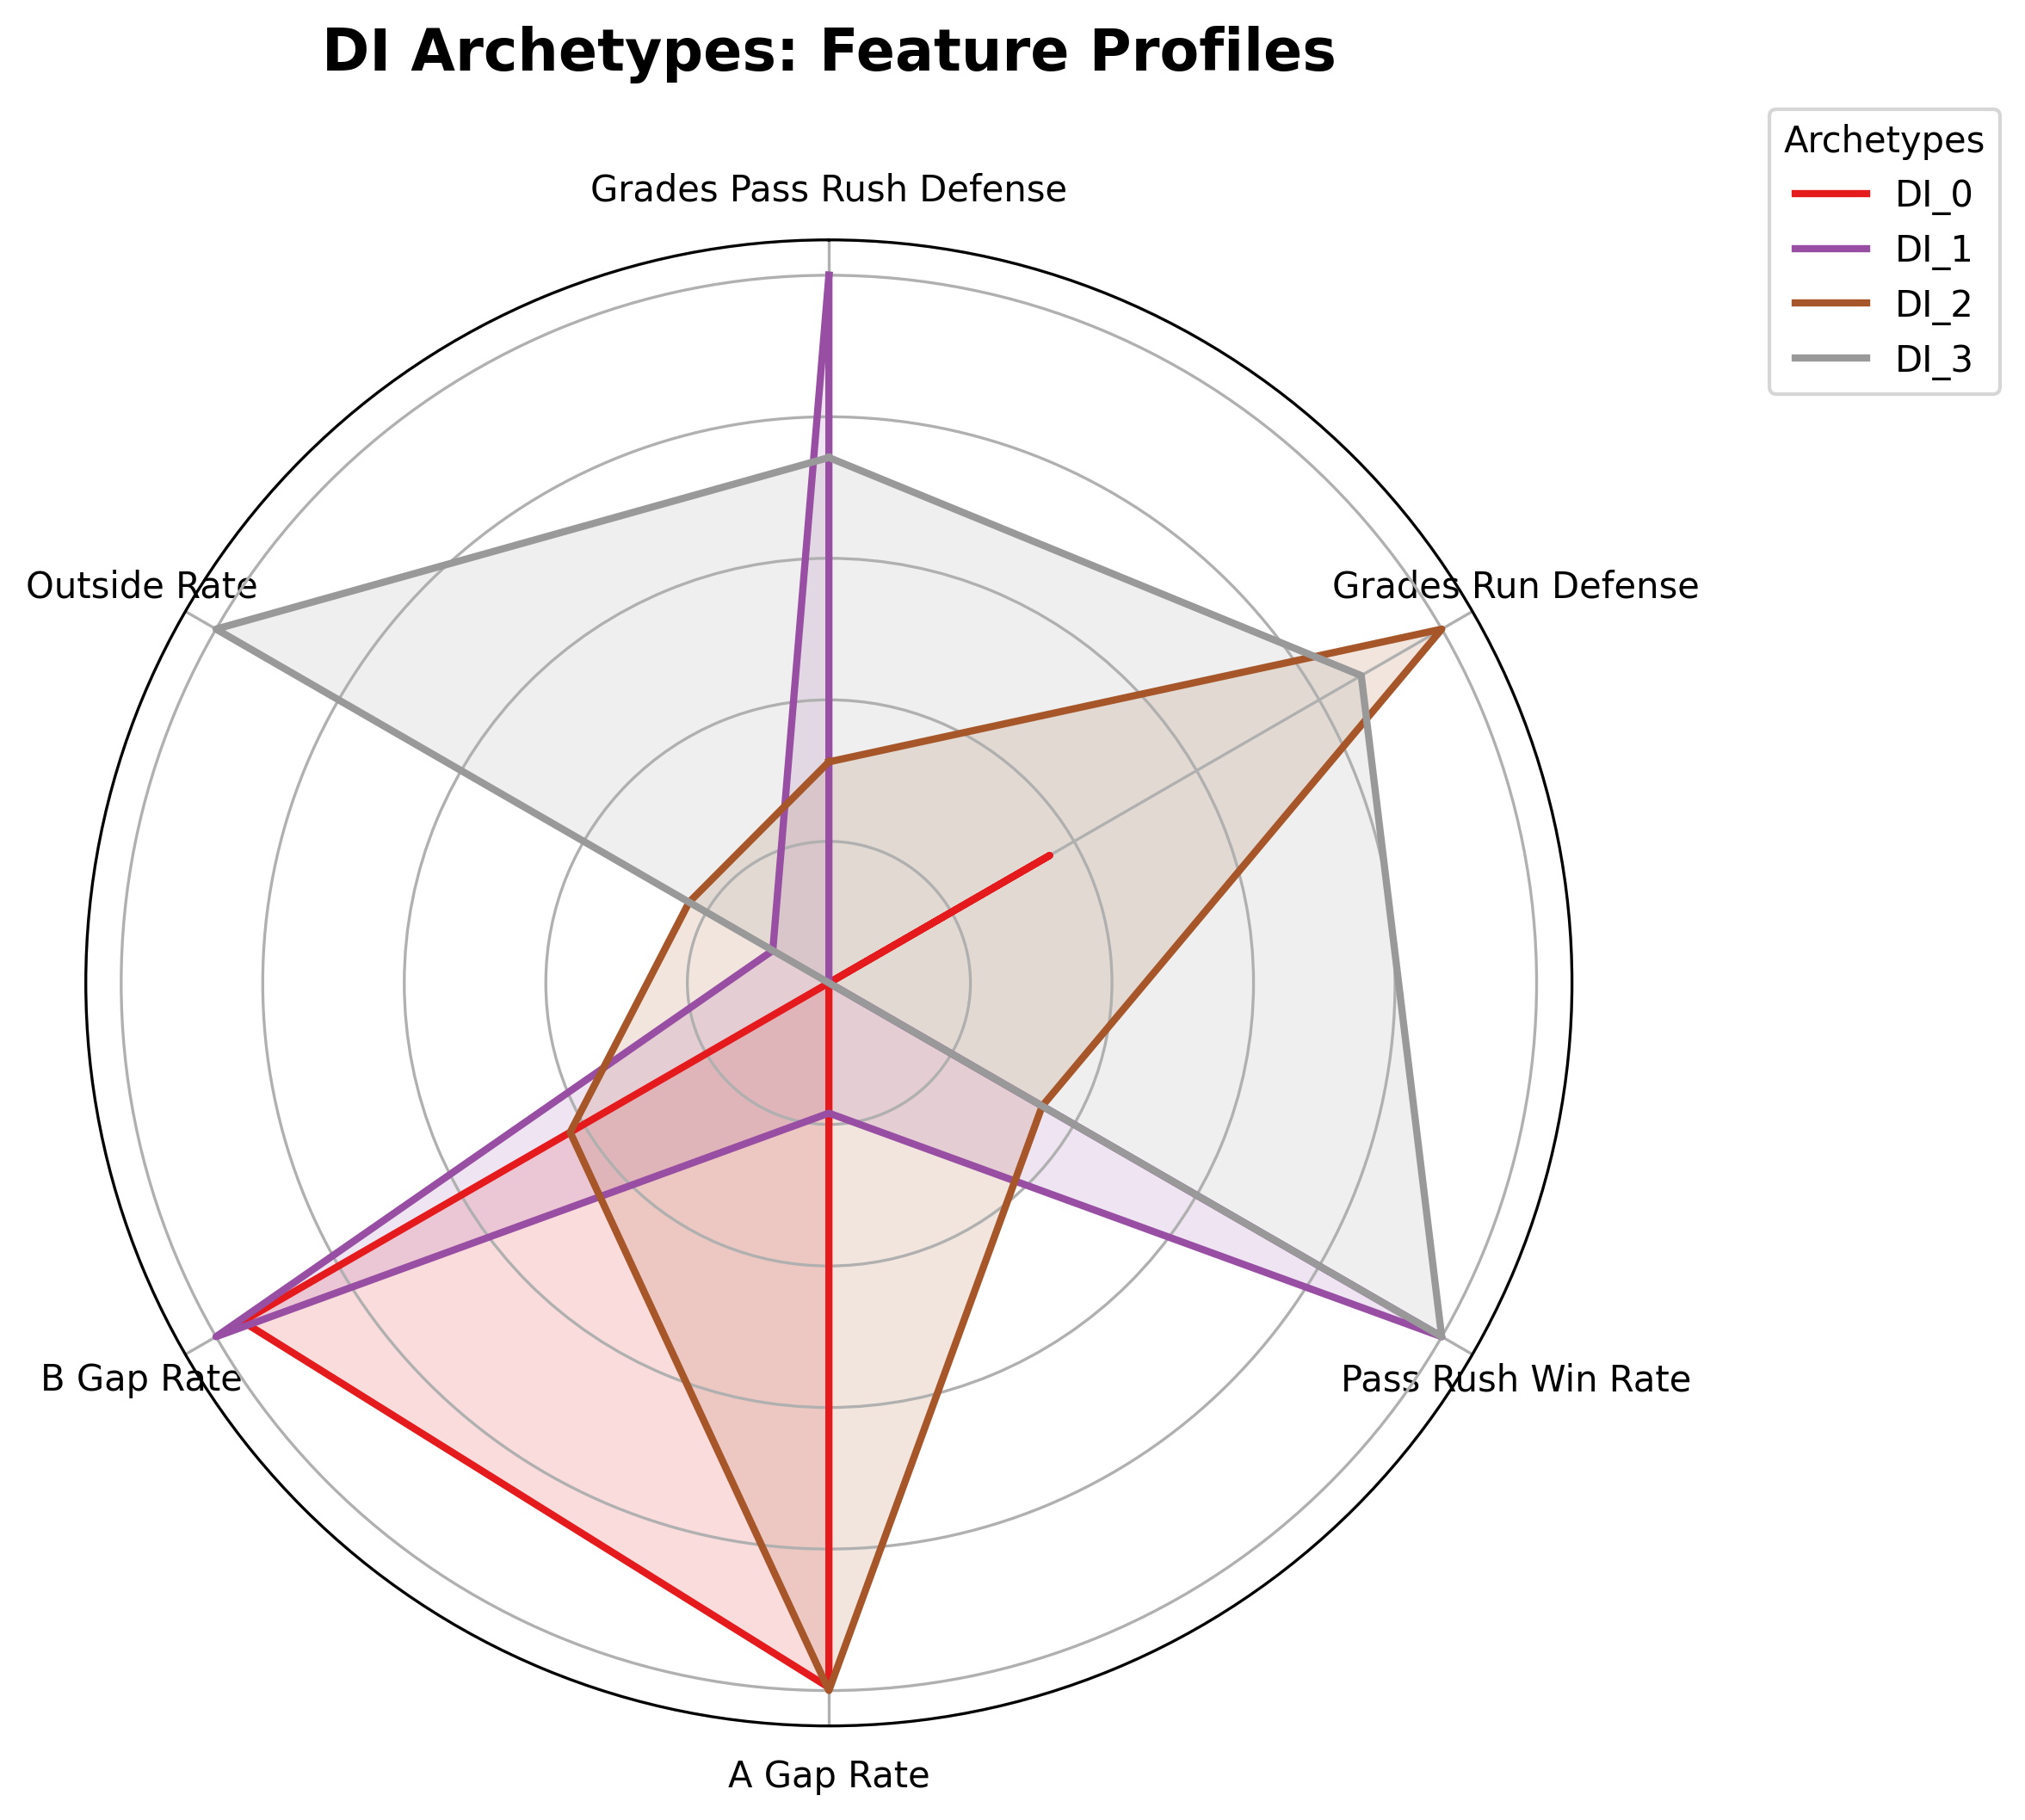

In [ ]:
from IPython.display import Image, display

# Display the mean feature values for Defensive Interior Clusters
print("--- Mean Feature Values for Defensive Interior Clusters ---")
display(grouped_stats_di)

# Display the radar_DI.png image
print("\n--- Visualizing Defensive Interior Archetypes (radar_DI.png) ---")
display(Image(filename='radar_DI.png'))

### Analyze Defensive Interior (DI) Cluster Characteristics

Here are the mean feature values for each Defensive Interior cluster, followed by an analysis of each archetype:

| dominant_cluster | grades_pass_rush_defense | grades_run_defense | pass_rush_win_rate | a_gap_rate | b_gap_rate | outside_rate |
|:---|:---|:---|:---|:---|:---|:---|
| DI_0 | 59.656296 | 54.905926 | 5.442222 | 0.252461 | 0.700432 | 0.000000 |
| DI_1 | 65.990798 | 54.275460 | 8.998160 | 0.069764 | 0.709586 | 0.011540 |
| DI_2 | 61.635106 | 56.026596 | 6.679787 | 0.253431 | 0.587524 | 0.028749 |
| DI_3 | 64.359091 | 55.796465 | 8.997475 | 0.028335 | 0.498346 | 0.126054 |

Here's an interpretation of each DI cluster:

*   **DI_0: "Traditional Run-Stuffing Nose Tackle"**
    *   **Explanation**: This archetype is characterized by the highest `b_gap_rate` (`0.700`) and an `outside_rate` of `0.000`, indicating a primary role of anchoring the interior against the run. Their `grades_run_defense` (`54.91`) is higher than their `grades_pass_rush_defense` (`59.66`) and their `pass_rush_win_rate` (`5.44`) is the lowest, suggesting a focus on occupying blockers and stuffing interior runs, primarily in the B-gap.
*   **DI_1: "Interior Pass Rusher (B-Gap Specialist)"**
    *   **Explanation**: This cluster shows the highest `grades_pass_rush_defense` (`65.99`) and `pass_rush_win_rate` (`8.998`), indicating highly effective pass rushers. They are primarily characterized by a very high `b_gap_rate` (`0.710`), suggesting they frequently attack the B-gap, while their `a_gap_rate` (`0.069`) is relatively low. Their `outside_rate` (`0.012`) is also very low, confirming a focused interior role. This profile describes a player who excels at disrupting passing plays from the interior, with a clear emphasis on the B-gap, and less focus on run defense (lowest `grades_run_defense`).
*   **DI_2: "Versatile Interior Disruptor"**
    *   **Explanation**: This archetype exhibits a balanced profile across run and pass defense, with a good `grades_pass_rush_defense` (`61.64`) and `grades_run_defense` (`56.03`). They have the highest `a_gap_rate` (`0.253`) and a moderate `b_gap_rate` (`0.588`), indicating versatility in attacking both interior gaps. Their `pass_rush_win_rate` (`6.68`) is solid, and their `outside_rate` (`0.029`) is low but not zero, suggesting they can slightly influence outside plays. This player can be effective in various interior roles.
*   **DI_3: "Edge-Leaning Pass Rusher"**
    *   **Explanation**: This cluster has the highest `outside_rate` (`0.126`) among DI players, suggesting they often align or drift to the outside shoulders of offensive linemen, almost like an interior-edge hybrid. They boast excellent `grades_pass_rush_defense` (`64.36`) and `pass_rush_win_rate` (`8.997`), indicating strong pass-rushing capabilities. Their `a_gap_rate` (`0.028`) is the lowest, and their `b_gap_rate` (`0.498`) is moderate, further emphasizing their tendency to attack from the exterior of the interior. Their run defense (`55.80`) is consistent with other interior linemen, but their pass-rush ability is their key strength.